# Configurações

In [1]:
# Extensão que verifica se um dos arquivos foi alterado
%load_ext autoreload
%autoreload 2

In [24]:
# Obtendo a seed para aleatoriedades
from c0_configuracoes import seed


In [3]:
# Bibliotecas

from aif360.algorithms.postprocessing import RejectOptionClassification
from aif360.algorithms.preprocessing import DisparateImpactRemover
from aif360.algorithms.preprocessing.reweighing import Reweighing
from aif360.datasets import BinaryLabelDataset
from collections import defaultdict
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import DemographicParity
from imblearn.over_sampling import SMOTENC
import inspect
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import chi2_contingency
import seaborn as sns
import shap
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from tabulate import tabulate
from ucimlrepo import fetch_ucirepo
import xgboost as xgb

c:\Users\Gabriel\Documents\IC\Codigo\venv\Lib\site-packages\inFairness\utils\ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
c:\Users\Gabriel\Documents\IC\Codigo\venv\Lib\site-packages\inFairness\utils\ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vec

## Testes modelos


----- Dataset || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.82      0.96      0.88      6805
           1       0.66      0.25      0.36      1958

    accuracy                           0.80      8763
   macro avg       0.74      0.60      0.62      8763
weighted avg       0.78      0.80      0.77      8763

ROC AUC: 0.7147
F1 Score: 0.3577
KS: 0.3641

----- Dataset || MATRIZ DE CONFUSÃO -----



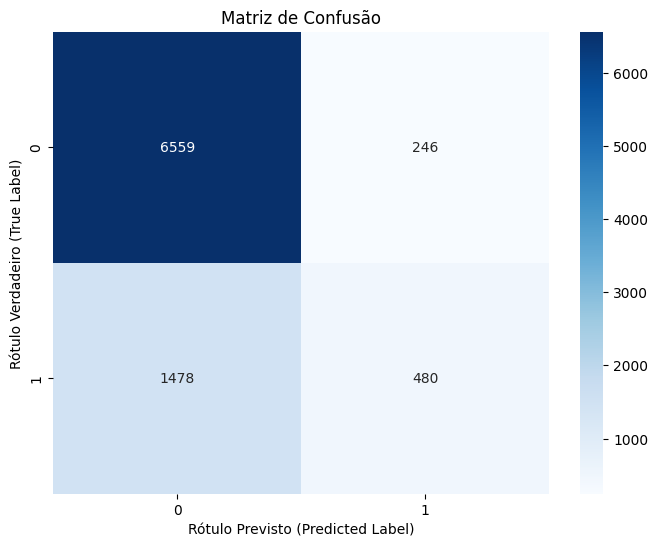


----- Dataset || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Desprivilegiado): 0.0727
Selection Rate (Privilegiado):   0.0987
Demographic Parity Difference: -0.0260
Demographic Parity Ratio:    0.7364

----- True Positive Rate (Equal Opportunity) -----
True Positive Rate (Desprivilegiado): 0.2396
True Positive Rate (Privilegiado):   0.2524
True Positive Rate Difference: -0.0127
True Positive Rate Ratio:      0.9496

----- False Positive Rate -----
False Positive Rate (Desprivilegiado): 0.0290
False Positive Rate (Privilegiado):   0.0480
False Positive Rate Difference: -0.0189
False Positive Rate Ratio:      0.6050

----- False Negative Rate -----
False Negative Rate (Desprivilegiado): 0.7604
False Negative Rate (Privilegiado):   0.7476
False Negative Rate Difference: 0.0127
False Negative Rate Ratio:      1.0170

----- Predictive Parity (Precision) -----
Precision (Desprivilegiado): 0.6838
Precision (Privilegiado):   0.6350
Predictive Parit

In [41]:
from c2_3_random_forest import random_forest_GSCV
from c2_4_xgboost import xgboost_GSCV
from c2_5_regressao_logistica import regressao_logistica_GSCV
from c2_6_perceptron import perceptron_GSCV

from c0_configuracoes import (
    param_grid_regressao_logistica_completo, 
    param_grid_perceptron_completo, 
    param_grid_random_forest_completo, 
    param_grid_xgboost_completo
)

df1_original = pd.read_csv(f"Datasets/Processados/Dataset1.csv", sep=',')
df2_original = pd.read_csv(f"Datasets/Processados/Dataset2.csv", sep=',')
df3_original = pd.read_csv(f"Datasets/Processados/Dataset3.csv", sep=',')
df4_original = pd.read_csv(f"Datasets/Processados/Dataset4.csv", sep=',')

testar = True
if(testar):
  funcao_modelo = regressao_logistica_GSCV
  # funcao_modelo = perceptron_GSCV
  # funcao_modelo = random_forest_GSCV
  # funcao_modelo = xgboost_GSCV

  base_de_dados = df1_original
  num_base_de_dados = 1
  funcao_parametros = {}

  # TREINANDO UM MODELO

  # Obtendo as features e o rótulo
  X = base_de_dados.drop('target', axis=1)
  y = base_de_dados['target']

  # Separando os dados 70% treino e 30% teste
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

  dataset_treino = pd.concat([X_train, y_train], axis=1)
  dataset_teste = pd.concat([X_test, y_test], axis=1)

  dataset_treino.to_csv('dataset_treino.csv', index=False)
  dataset_teste.to_csv('dataset_teste.csv', index=False)

  parametros_grid = None
  if   funcao_modelo == regressao_logistica_GSCV:
      parametros_grid = param_grid_regressao_logistica_completo
  elif funcao_modelo == perceptron_GSCV:
      parametros_grid = param_grid_perceptron_completo
  elif funcao_modelo == random_forest_GSCV:
      parametros_grid = param_grid_random_forest_completo
  elif funcao_modelo == xgboost_GSCV:
      parametros_grid = param_grid_xgboost_completo

  preprocessor = None
  if num_base_de_dados == 1:
      # Pré-processamento - LIM_BAL, BILL_AMT, PAY_AMT - StandardScaler
      numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
      nominal_cols = []
      preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
        ],
        remainder='passthrough'
      )
  elif num_base_de_dados == 2:
      # Colunas numéricas - StandardScaler
      numerical_cols = ['AMT_INCOME_TOTAL']
      # Colunas categóricas nominais - One-Hot Encoder
      nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']

      preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
        ],
        remainder='passthrough'
      )

  elif num_base_de_dados == 3:
      # Colunas numéricas - StandardScaler
      numerical_cols = [
          'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
          'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
          'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
          'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
          'Total_Revolving_Bal'
      ]
      # Colunas categóricas nominais - One-Hot Encoder
      nominal_cols = ['Marital_Status']
      # Colunas categóricas ordinais - Ordinal Encoder
      ordinal_cols = ['Education_Level', 'Income_Category', 'Card_Category']
      # Definição da ordem
      education_order = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
      income_order = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']
      card_order = ['Blue', 'Silver', 'Gold', 'Platinum']

      preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols),
            ('ord', OrdinalEncoder(categories=[education_order, income_order, card_order], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
        ],
        remainder='passthrough'
      )
  else:
      # Colunas numéricas contínuas - StandardScaler
      numerical_cols = ['Attribute2', 'Attribute5']
      # Colunas categóricas - OneHotEncoder
      categorical_cols = ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute10', 
                          'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20']
      preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
      )

  # Dados sensíveis - Os mesmos para todos os datasets
  dados_sensiveis = {}
  dados_sensiveis['coluna_sensivel'] = 'sensitive_sexo'
  dados_sensiveis['grupo_privilegiado'] =  1
  dados_sensiveis['grupo_desprivilegiado'] = 0
  dados_sensiveis['rotulo_favoravel'] = 0
  dados_sensiveis['rotulo_desfavoravel'] = 1

  # Parâmetros gerais
  funcao_parametros['param_grid'] = parametros_grid
  funcao_parametros['preprocessor'] = preprocessor
  funcao_parametros['cv_n_splits'] = 5
  funcao_parametros['nome_base_de_dados'] = "Dataset"
  funcao_parametros['X_train'] = X_train
  funcao_parametros['X_test'] = X_test
  funcao_parametros['y_train'] = y_train
  funcao_parametros['y_test'] = y_test
  funcao_parametros['dados_sensiveis'] = dados_sensiveis
  funcao_parametros['printar'] = True
  funcao_parametros['matriz_de_confusao'] = True
  funcao_parametros['grafico_shap'] = False

  _, desempenho = funcao_modelo(**funcao_parametros)
  print(desempenho["melhores_parametros"])

# Pré-Processamento

## Instance Reweighing

In [ ]:
def instance_reweighing(dados_sensiveis, funcao_modelo, parametros_in, printar=False):
  parametros = parametros_in.copy()

  # Ajustando o nome
  parametros['nome_base_de_dados'] = parametros['nome_base_de_dados'] + " || INSTANCE REWEIGHING"

  # Definindo os grupos privilegiados e desprivilegiados
  privileged_groups = {dados_sensiveis['coluna_sensivel']: dados_sensiveis['grupo_privilegiado']}
  unprivileged_groups = {dados_sensiveis['coluna_sensivel']: dados_sensiveis['grupo_desprivilegiado']}

  # Formando o dataset de treino
  dados_treino = pd.concat([parametros['X_train'], parametros['y_train']], axis=1)

  # Convertendo o DataFrame do Pandas para o formato do AIF360
  dataset_orig = BinaryLabelDataset(
      df=dados_treino,
      favorable_label=dados_sensiveis['rotulo_favoravel'],
      unfavorable_label=dados_sensiveis['rotulo_desfavoravel'],
      label_names=['TARGET'],
      protected_attribute_names=dados_sensiveis['coluna_sensivel']
  )

  RW = Reweighing(unprivileged_groups=unprivileged_groups,
                  privileged_groups=privileged_groups)

  dataset_transf = RW.fit_transform(dataset_orig)
  weights = pd.Series(dataset_transf.instance_weights, index=dados_treino.index)

  # Resultados
  temp_df = dados_treino.copy()
  temp_df['weight'] = weights
  pesos_por_classe = temp_df.groupby([dados_sensiveis['coluna_sensivel'][0], 'TARGET'])['weight'].mean()
  if(printar):
    print(f"\n----- {parametros['nome_base_de_dados']} || PESOS CALCULADOS -----\n")
    print(pesos_por_classe)

  # TREINANDO UM MODELO

  # Parâmetros já contém os dados de treino e teste e o nome dos dados
  # Parâmetros específicos dessa técnica
  parametros['pesos'] = True
  parametros['pesos_modelo'] = weights

  _, desempenho = funcao_modelo(**parametros)
  desempenho["pesos_das_classes"] = pesos_por_classe

  return(desempenho)

In [ ]:
# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# base_de_dados = df1_original.copy()
# base_de_dados.name = df1_original.name
# X = base_de_dados.drop('TARGET', axis=1)
# y = base_de_dados['TARGET']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_random_forest
# parametros['preprocessor'] = preprocessor1
# parametros['cv_n_splits'] = 2
# parametros['X_train'] = X_train
# parametros['X_test'] = X_test
# parametros['y_train'] = y_train
# parametros['y_test'] = y_test
# parametros['nome_base_de_dados'] = base_de_dados.name

# dados_sensiveis = {}
# dados_sensiveis['coluna_sensivel'] = ['SEX_MALE']
# dados_sensiveis['grupo_privilegiado'] = [{'SEX_MALE': 1}]
# dados_sensiveis['grupo_desprivilegiado'] = [{'SEX_MALE': 0}]
# dados_sensiveis['rotulo_favoravel'] = 0
# dados_sensiveis['rotulo_desfavoravel'] = 1

# desempenho = instance_reweighing(dados_sensiveis, random_forest_GSCV, parametros, printar=True)

## Disparate Impact Removal

In [340]:
from aif360.algorithms import Transformer

# Adaptação para a técnica contendo o método fit() e transform()
class DisparateImpactRemover_Mod(Transformer):
    
    def __init__(self, repair_level=1.0, sensitive_attribute=''):
        super(DisparateImpactRemover_Mod, self).__init__(repair_level=repair_level)
        from BlackBoxAuditing.repairers.GeneralRepairer import Repairer
        self.Repairer = Repairer

        if not 0.0 <= repair_level <= 1.0:
            raise ValueError("'repair_level' must be between 0.0 and 1.0.")

        self.repair_level = repair_level
        self.sensitive_attribute = sensitive_attribute
        self.repairer_ = None      # armazenará o reparador treinado
        self.index_ = None         # índice do atributo sensível
        self.fitted_ = False       # flag para saber se o fit foi feito

    # --- NOVO: método fit() ---
    def fit(self, dataset):
        """Aprende o reparador a partir do dataset de treino."""
        if not self.sensitive_attribute:
            self.sensitive_attribute = dataset.protected_attribute_names[0]

        features = dataset.features.tolist()
        self.index_ = dataset.feature_names.index(self.sensitive_attribute)

        # cria e armazena o reparador (não aplica ainda)
        self.repairer_ = self.Repairer(features, self.index_, self.repair_level, False)
        self.fitted_ = True
        return self

    # --- NOVO: método transform() ---
    def transform(self, dataset):
        """Aplica o reparo usando o reparador já aprendido no fit()."""
        if not self.fitted_:
            raise RuntimeError("Você precisa chamar fit() antes de transform().")

        features = dataset.features.tolist()
        repaired = dataset.copy()

        # usa o mesmo reparador treinado no fit()
        repaired_features = self.repairer_.repair(features)
        repaired.features = np.array(repaired_features, dtype=np.float64)

        # garante que o atributo sensível original não seja alterado
        idx_sa = dataset.protected_attribute_names.index(self.sensitive_attribute)
        repaired.features[:, self.index_] = repaired.protected_attributes[:, idx_sa]

        return repaired

    # --- Mantém compatibilidade com o padrão original ---
    def fit_transform(self, dataset):
        """Treina o reparador e aplica o reparo no mesmo dataset."""
        return self.fit(dataset).transform(dataset)

In [ ]:
def disparate_impact_removal(dados_sensiveis, funcao_modelo, parametros_in, printar=False):
  parametros = parametros_in.copy()

  # Ajustando o nome
  parametros['nome_base_de_dados'] = parametros['nome_base_de_dados'] + " || DISPARATE IMPACT REMOVAL"

  # Formando o dataset de treino
  dados_treino = pd.concat([parametros['X_train'], parametros['y_train']], axis=1)

  # Convertendo o DataFrame do Pandas para o formato do AIF360
  dataset_train = BinaryLabelDataset(
      df=dados_treino,
      favorable_label=dados_sensiveis['rotulo_favoravel'],
      unfavorable_label=dados_sensiveis['rotulo_desfavoravel'],
      label_names=['TARGET'],
      protected_attribute_names=dados_sensiveis['coluna_sensivel']
  )

  # Aplicando a técnica
  DIR = DisparateImpactRemover_Mod(repair_level=1.0)
  dataset_repaired_train = DIR.fit_transform(dataset_train)

  # Voltando para o dataframe
  df_repaired_train, _ = dataset_repaired_train.convert_to_dataframe()

  # Formando os dados de teste e aplicando o transform neles
  dados_teste = pd.concat([parametros['X_test'], parametros['y_test']], axis=1)

  dataset_test = BinaryLabelDataset(
      df=dados_teste,
      favorable_label=dados_sensiveis['rotulo_favoravel'],
      unfavorable_label=dados_sensiveis['rotulo_desfavoravel'],
      label_names=['TARGET'],
      protected_attribute_names=dados_sensiveis['coluna_sensivel']
  )

  # Aplicando a transformação sem dar fit de novo
  dataset_repaired_test = DIR.transform(dataset_test)

  # Voltando para o dataframe
  df_repaired_test, _ = dataset_repaired_test.convert_to_dataframe()

  # Separando X_test e y_test do DataFrame reparado
  parametros['X_train'] = df_repaired_train.drop('TARGET', axis=1)
  parametros['y_train'] = df_repaired_train['TARGET']
  parametros['X_test'] = df_repaired_test.drop('TARGET', axis=1)
  parametros['y_test'] = df_repaired_test['TARGET']

  if(printar):
    print(f"\n----- {parametros['nome_base_de_dados']} || VISUALIZANDO AS MUDANÇAS -----\n")
    print("Visualização do DataFrame Original de Treino:")
    print(dados_treino.head())
    print("\nVisualização do DataFrame Reparado de Treino:")
    print(df_repaired_train.head())
    print("\nVisualização do DataFrame Original de Teste:")
    print(dados_teste.head())
    print("\nVisualização do DataFrame Reparado de Teste:")
    print(df_repaired_test.head())

  # TREINANDO UM MODELO

  X_test_justica = parametros['X_test'].copy()

  # Excluir a coluna sensível - Próprio da técnica
  parametros['X_train'] = parametros['X_train'].drop(dados_sensiveis['coluna_sensivel'][0], axis=1)
  parametros['X_test'] = parametros['X_test'].drop(dados_sensiveis['coluna_sensivel'][0], axis=1)
  if(printar):
    print(f"A coluna {dados_sensiveis['coluna_sensivel'][0]} não foi usada no treinamento do modelo")

  # Parâmetros já contém os dados de treino e teste e o nome dos dados
  # Parâmetros específicos dessa técnica
  parametros['X_justica'] = True
  parametros['X_test_justica'] = X_test_justica

  _, desempenho = funcao_modelo(**parametros)

  return(desempenho)

In [ ]:
# numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
# preprocessor1 = ColumnTransformer(
# transformers=[('num', StandardScaler(), numerical_features)],
#     remainder='passthrough', verbose_feature_names_out=False
# )

# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# param_grid_random_forest = {
#     'classifier__random_state': [seed],
#     'classifier__n_estimators': [100],
#     'classifier__max_depth': [10]
# }

# base_de_dados = df1_original.copy()
# base_de_dados.name = df1_original.name
# X = base_de_dados.drop('TARGET', axis=1)
# y = base_de_dados['TARGET']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_random_forest
# parametros['preprocessor'] = preprocessor1
# parametros['cv_n_splits'] = 2
# parametros['X_train'] = X_train
# parametros['X_test'] = X_test
# parametros['y_train'] = y_train
# parametros['y_test'] = y_test
# parametros['nome_base_de_dados'] = base_de_dados.name

# dados_sensiveis = {}
# dados_sensiveis['coluna_sensivel'] = ['SEX_MALE']
# dados_sensiveis['grupo_privilegiado'] = [{'SEX_MALE': 1}]
# dados_sensiveis['grupo_desprivilegiado'] = [{'SEX_MALE': 0}]
# dados_sensiveis['rotulo_favoravel'] = 0
# dados_sensiveis['rotulo_desfavoravel'] = 1

# desempenho = disparate_impact_removal(dados_sensiveis, random_forest_GSCV, parametros, printar=True)

## Synthetic Data Generation

In [ ]:
def synthetic_data_generation(dados_sensiveis, funcao_modelo, parametros_in, colunas_discretas, printar=False):
  parametros = parametros_in.copy()

  # Ajustando o nome
  nome_banco_teste = parametros['nome_base_de_dados'] + " || DADOS DE TESTE || SYNTHETIC DATA GENERATION"

  coluna_sensivel = dados_sensiveis['coluna_sensivel'][0]

  # Formando o dataset de treino
  dados_treino = pd.concat([parametros['X_train'], parametros['y_train']], axis=1)

  # Descobrindo a razão para o target de cada sexo
  contagem_grupos = dados_treino.groupby([coluna_sensivel, 'TARGET']).size()
  razao_target_mulheres = contagem_grupos.loc[(0, 1)] / contagem_grupos.loc[(0, 0)]
  razao_target_homens = contagem_grupos.loc[(1, 1)] / contagem_grupos.loc[(1, 0)]

  if(printar):
    print(f"\n----- {nome_banco_teste} || DISTRIBUIÇÃO DOS DADOS DE TESTE RECEBIDOS\n")
    print(contagem_grupos)
    print("Razão de target == 1 / target == 0: ")
    print(f"Mulheres: {razao_target_mulheres}")
    print(f"Homens: {razao_target_homens}\n")

  # Separar os dados por gênero
  df_mulheres = dados_treino[dados_treino[coluna_sensivel] == 0].copy()
  df_homens = dados_treino[dados_treino[coluna_sensivel] == 1].copy()

  # Separar features (X) e target (y) para o subgrupo de mulheres
  X_mulheres = df_mulheres.drop('TARGET', axis=1)
  y_mulheres = df_mulheres['TARGET']

  # Identificando as colunas categóricas
  categorical_features_indices = [X_mulheres.columns.get_loc(col) for col in colunas_discretas]

  if(razao_target_mulheres > razao_target_homens):
    nova_quantidade = int(contagem_grupos.loc[(0, 1)] / razao_target_homens)
    estrategia_mulheres = {0: nova_quantidade}
    if(printar):
      print(f"Aumentando o número de mulheres com target == 0 para {nova_quantidade}")
  else:
    nova_quantidade = int(contagem_grupos.loc[(0, 0)] * razao_target_homens)
    estrategia_mulheres = {1: nova_quantidade}
    if(printar):
      print(f"Aumentando o número de mulheres com target == 1 para {nova_quantidade}")

  smotenc = SMOTENC(sampling_strategy=estrategia_mulheres, categorical_features=categorical_features_indices, random_state=seed)

  # Aplicar o SMOTENC
  X_mulheres_resampled, y_mulheres_resampled = smotenc.fit_resample(X_mulheres, y_mulheres)

  # Reconstruir o DataFrame de mulheres com os novos dados sintéticos
  df_mulheres_resampled = pd.concat([
      pd.DataFrame(X_mulheres_resampled, columns=X_mulheres.columns),
      pd.Series(y_mulheres_resampled, name='TARGET')
  ], axis=1)

  # Juntar o grupo de homens (intocado) com o novo grupo de mulheres (modificado)
  df_synthetic_data_generation = pd.concat([df_homens, df_mulheres_resampled], ignore_index=True)
  nome_banco_sintetico = parametros['nome_base_de_dados'] + " || DADOS DE TESTE COM SDG || SYNTHETIC DATA GENERATION"

  contagem_grupos = df_synthetic_data_generation.groupby([coluna_sensivel, 'TARGET']).size()
  razao_target_mulheres = contagem_grupos.loc[(0, 1)] / contagem_grupos.loc[(0, 0)]
  razao_target_homens = contagem_grupos.loc[(1, 1)] / contagem_grupos.loc[(1, 0)]

  if(printar):
    print(f"Tamanho total do DataFrame de teste: {dados_treino.shape[0]} linhas")
    print(f"\n----- {nome_banco_sintetico} || DISTRIBUIÇÃO FINAL DOS DADOS DE TESTE\n")
    print(df_synthetic_data_generation.groupby([coluna_sensivel, 'TARGET']).size())
    print("Razão de target = 1 / target = 0: ")
    print(f"Mulheres: {razao_target_mulheres}")
    print(f"Homens: {razao_target_homens}")
    print(f"Tamanho total do novo DataFrame de teste: {df_synthetic_data_generation.shape[0]} linhas")

  # Balanceando os dados novos
  base_de_dados_final = df_synthetic_data_generation
  nome_final = nome_banco_sintetico

  if("BANCEADO" in parametros['nome_base_de_dados']):
    base_de_dados_final, estatisticas = balancear(df_synthetic_data_generation, nome_banco_sintetico, 'TARGET', printar=printar)
    nome_final = parametros['nome_base_de_dados'] + " COM SDG BALANCEADO || SYNTHETIC DATA GENERATION"

  parametros['nome_base_de_dados'] = nome_final
  
  # Atualizando os dados de treino para o modelo
  parametros['X_train'] = base_de_dados_final.drop('TARGET', axis=1)
  parametros['y_train'] = base_de_dados_final['TARGET']

  # TREINANDO UM MODELO

  # Parâmetros já contém os dados de treino e teste e o nome dos dados
  # Parâmetros específicos dessa técnica - Não há

  _, desempenho = funcao_modelo(**parametros)

  return(desempenho)

In [ ]:
# numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
# preprocessor1 = ColumnTransformer(
# transformers=[('num', StandardScaler(), numerical_features)],
#     remainder='passthrough', verbose_feature_names_out=False
# )

# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# param_grid_random_forest = {
#     'classifier__random_state': [seed],
#     'classifier__n_estimators': [100],
#     'classifier__max_depth': [10]
# }

# base_de_dados = df1_original.copy()
# base_de_dados.name = df1_original.name
# X = base_de_dados.drop('TARGET', axis=1)
# y = base_de_dados['TARGET']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_random_forest
# parametros['preprocessor'] = preprocessor1
# parametros['cv_n_splits'] = 2
# parametros['X_train'] = X_train
# parametros['X_test'] = X_test
# parametros['y_train'] = y_train
# parametros['y_test'] = y_test
# parametros['nome_base_de_dados'] = base_de_dados.name

# dados_sensiveis = {}
# dados_sensiveis['coluna_sensivel'] = ['SEX_MALE']
# dados_sensiveis['grupo_privilegiado'] = [{'SEX_MALE': 1}]
# dados_sensiveis['grupo_desprivilegiado'] = [{'SEX_MALE': 0}]
# dados_sensiveis['rotulo_favoravel'] = 0
# dados_sensiveis['rotulo_desfavoravel'] = 1

# colunas_discretas1 = [
#     'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
# ]

# desempenho = synthetic_data_generation(dados_sensiveis, random_forest_GSCV, parametros, colunas_discretas1, printar=True)

## Suppression

In [ ]:
def suppression(dados_sensiveis, funcao_modelo, parametros_in, printar=False):
  parametros = parametros_in.copy()

  # Ajustando o nome
  parametros['nome_base_de_dados'] = parametros['nome_base_de_dados'] + " || SUPPRESSION"

  coluna_sensivel = dados_sensiveis['coluna_sensivel'][0]

  # TREINANDO UM MODELO

  # Excluir a coluna sensível - Próprio da técnica
  X_test_justica = parametros['X_test'].copy()
  parametros['X_train'] = parametros['X_train'].drop(coluna_sensivel, axis=1)
  parametros['X_test'] = parametros['X_test'].drop(coluna_sensivel, axis=1)
  if(printar):
    print(f"A coluna {coluna_sensivel} não foi usada no treinamento do modelo")

  # Parâmetros já contém os dados de treino e teste e o nome dos dados
  # Parâmetros específicos dessa técnica
  parametros['X_justica'] = True
  parametros['X_test_justica'] = X_test_justica

  _, desempenho = funcao_modelo(**parametros)

  return(desempenho)

In [ ]:
# numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
# preprocessor1 = ColumnTransformer(
# transformers=[('num', StandardScaler(), numerical_features)],
#     remainder='passthrough', verbose_feature_names_out=False
# )

# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# param_grid_random_forest = {
#     'classifier__random_state': [seed],
#     'classifier__n_estimators': [100],
#     'classifier__max_depth': [10]
# }

# base_de_dados = df2_original.copy()
# base_de_dados.name = df2_original.name
# X = base_de_dados.drop('TARGET', axis=1)
# y = base_de_dados['TARGET']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# # Instanciando e treinando pré-processador
# preprocessor = preprocessor2
# preprocessor.fit(X_train)

# # Transformando os dados
# X_train_processed = preprocessor.transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

# # Criando DataFrames para os dados processados de treino. Dados de teste são binários, logo não é preciso usar o pré-processador
# X_train_processed_df = pd.DataFrame(X_train_processed, index=X_train.index, columns=preprocessor.get_feature_names_out())
# X_test_processed_df = pd.DataFrame(X_test_processed, index=X_test.index, columns=preprocessor.get_feature_names_out())

# # Passando os dados em dataframes já separados
# parametros= {}
# parametros['X_train'] = X_train_processed_df
# parametros['X_test'] = X_test_processed_df
# parametros['y_train'] = y_train
# parametros['y_test'] = y_test

# # Pré-processador que não faz nada
# preprocessor_passthrough = ColumnTransformer(
#   transformers=[],
#   remainder='passthrough',
#   verbose_feature_names_out=False
# )

# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_xgboost
# parametros['preprocessor'] = preprocessor_passthrough
# parametros['cv_n_splits'] = 2
# parametros['nome_base_de_dados'] = base_de_dados.name

# dados_sensiveis = {}
# dados_sensiveis['coluna_sensivel'] = ['SEX_MALE']
# dados_sensiveis['grupo_privilegiado'] = [{'SEX_MALE': 1}]
# dados_sensiveis['grupo_desprivilegiado'] = [{'SEX_MALE': 0}]
# dados_sensiveis['rotulo_favoravel'] = 0
# dados_sensiveis['rotulo_desfavoravel'] = 1

# colunas_discretas1 = [
#     'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
# ]

# desempenho = suppression(dados_sensiveis, xgboost_GSCV, parametros, printar=True)

# Pós-Processamento

In [347]:
%matplotlib inline

## Threshold Optimization

In [ ]:
def threshold_optimization(dados_sensiveis, funcao_modelo, parametros_in, printar=False):
  parametros = parametros_in.copy()

  # Ajustando o nome
  parametros['nome_base_de_dados'] = parametros['nome_base_de_dados'] + " || THRESHOLD OPTIMIZATION"

  coluna_sensivel = dados_sensiveis['coluna_sensivel'][0]

  # Separando os dados de treino (70%*) em treino (55%*) e validação (15%*) *Em relação ao total de dados
  X_train, X_val, y_train, y_val = train_test_split(parametros['X_train'], parametros['y_train'], test_size=15/70, random_state=seed, stratify=parametros['y_train'])

  parametros['X_train'] = X_train
  parametros['y_train'] = y_train

  # TREINANDO UM MODELO

  # Parâmetros já contém os dados de treino e teste e o nome dos dados

  # Corrigindo o print e a matriz de confusão
  if 'printar' in parametros.keys():
    printar_resultado = parametros['printar']
    parametros['printar'] = False # Não printar o desempenho modelo original
  else:
    printar_resultado = False

  if 'matriz_de_confusao' in parametros.keys():
    matriz_de_confusao_resultado = parametros['matriz_de_confusao']
    parametros['matriz_de_confusao'] = False # Não printar o desempenho modelo original
  else:
    matriz_de_confusao_resultado = False

  # Treinar o modelo
  model, desempenho_base = funcao_modelo(**parametros)

  # THRESHOLD OPTIMIZATION

  X_test = parametros['X_test']
  y_test = parametros['y_test']

  # Atributo pessoal
  A_val = X_val[coluna_sensivel]
  A_test = X_test[coluna_sensivel]

  optimizer = ThresholdOptimizer(estimator=model, constraints='demographic_parity', prefit=True)
  optimizer.fit(X_val, y_val, sensitive_features=A_val)
  y_pred_threshold_optimization = optimizer.predict(X_test, sensitive_features=A_test)

  desempenho_threshold_optimization = desempenho_modelo(parametros['nome_base_de_dados'], model, X_test, X_test, y_pred_threshold_optimization, y_test, printar=printar_resultado, matriz_de_confusao=matriz_de_confusao_resultado)

  return(desempenho_base, desempenho_threshold_optimization)

In [ ]:
# numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
# preprocessor1 = ColumnTransformer(
# transformers=[('num', StandardScaler(), numerical_features)],
#     remainder='passthrough', verbose_feature_names_out=False
# )

# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# param_grid_random_forest = {
#     'classifier__random_state': [seed],
#     'classifier__n_estimators': [100],
#     'classifier__max_depth': [10]
# }

# base_de_dados = df1_original.copy()
# base_de_dados.name = df1_original.name
# X = base_de_dados.drop('TARGET', axis=1)
# y = base_de_dados['TARGET']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_xgboost
# parametros['preprocessor'] = preprocessor1
# parametros['cv_n_splits'] = 2
# parametros['X_train'] = X_train
# parametros['X_test'] = X_test
# parametros['y_train'] = y_train
# parametros['y_test'] = y_test
# parametros['nome_base_de_dados'] = base_de_dados.name

# dados_sensiveis = {}
# dados_sensiveis['coluna_sensivel'] = ['SEX_MALE']
# dados_sensiveis['grupo_privilegiado'] = [{'SEX_MALE': 1}]
# dados_sensiveis['grupo_desprivilegiado'] = [{'SEX_MALE': 0}]
# dados_sensiveis['rotulo_favoravel'] = 0
# dados_sensiveis['rotulo_desfavoravel'] = 1

# colunas_discretas1 = [
#     'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
# ]

# desempenho_orig, desempenho = threshold_optimization(dados_sensiveis, xgboost_GSCV, parametros, printar=True)

## Calibration

In [ ]:
def calibration(dados_sensiveis, funcao_modelo, parametros_in, printar=False):
  parametros = parametros_in.copy()

  # Ajustando o nome
  parametros['nome_base_de_dados'] = parametros['nome_base_de_dados'] + " || CALIBRATION"

  coluna_sensivel = dados_sensiveis['coluna_sensivel'][0]

  # Separando os dados de treino (70%*) em treino (55%*) e calibração (15%*) *Em relação ao total de dados
  X_train, X_calib, y_train, y_calib = train_test_split(parametros['X_train'], parametros['y_train'], test_size=15/70, random_state=seed, stratify=parametros['y_train'])

  parametros['X_train'] = X_train
  parametros['y_train'] = y_train

  # TREINANDO UM MODELO

  # Parâmetros já contém os dados de treino e teste e o nome dos dados

  # Corrigindo o print e a matriz de confusão
  if 'printar' in parametros.keys():
    printar_resultado = parametros['printar']
    parametros['printar'] = False # Não printar o desempenho modelo original
  else:
    printar_resultado = False

  if 'matriz_de_confusao' in parametros.keys():
    matriz_de_confusao_resultado = parametros['matriz_de_confusao']
    parametros['matriz_de_confusao'] = False # Não printar o desempenho modelo original
  else:
    matriz_de_confusao_resultado = False

  # Treinar o modelo
  model, desempenho_base = funcao_modelo(**parametros)

  # CALIBRATION

  X_test = parametros['X_test']
  y_test = parametros['y_test']

  # Obter a probabilidade da classe positiva (TARGET=1)
  probs_calib = model.predict_proba(X_calib)[:, 1]

  # Isolar dados de calibração para homens e mulheres
  is_male_calib = (X_calib[coluna_sensivel] == 1)
  is_female_calib = (X_calib[coluna_sensivel] == 0)

  # Calibrador para o grupo de homens
  calibrator_male = IsotonicRegression(out_of_bounds='clip')
  calibrator_male.fit(probs_calib[is_male_calib], y_calib[is_male_calib])

  # Calibrador para o grupo de mulheres
  calibrator_female = IsotonicRegression(out_of_bounds='clip')
  calibrator_female.fit(probs_calib[is_female_calib], y_calib[is_female_calib])

  # Obter probabilidades do modelo principal no conjunto de teste
  probs_test = model.predict_proba(X_test)[:, 1]

  # Separar os dados de teste por grupo
  is_male_test = (X_test[coluna_sensivel] == 1)
  is_female_test = (X_test[coluna_sensivel] == 0)

  # Aplicar o calibrador correspondente a cada grupo
  calibrated_probs_test = pd.Series(index=X_test.index, dtype=float)
  calibrated_probs_test[is_male_test] = calibrator_male.predict(probs_test[is_male_test])
  calibrated_probs_test[is_female_test] = calibrator_female.predict(probs_test[is_female_test])

  # Resultados
  y_pred_calibration = (calibrated_probs_test >= 0.5).astype(int)
  desempenho_calibration = desempenho_modelo(parametros['nome_base_de_dados'], model, X_test, X_test, y_pred_calibration, y_test, printar=printar_resultado, matriz_de_confusao=matriz_de_confusao_resultado)

  return(desempenho_base, desempenho_calibration)

In [ ]:
# numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
# preprocessor1 = ColumnTransformer(
# transformers=[('num', StandardScaler(), numerical_features)],
#     remainder='passthrough', verbose_feature_names_out=False
# )

# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# param_grid_random_forest = {
#     'classifier__random_state': [seed],
#     'classifier__n_estimators': [100],
#     'classifier__max_depth': [10]
# }

# base_de_dados = df2_original.copy()
# base_de_dados.name = df2_original.name
# X = base_de_dados.drop('TARGET', axis=1)
# y = base_de_dados['TARGET']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# # Instanciando e treinando pré-processador
# preprocessor = preprocessor2
# preprocessor.fit(X_train)

# # Transformando os dados
# X_train_processed = preprocessor.transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

# # Criando DataFrames para os dados processados de treino. Dados de teste são binários, logo não é preciso usar o pré-processador
# X_train_processed_df = pd.DataFrame(X_train_processed, index=X_train.index, columns=preprocessor.get_feature_names_out())
# X_test_processed_df = pd.DataFrame(X_test_processed, index=X_test.index, columns=preprocessor.get_feature_names_out())

# # Passando os dados em dataframes já separados
# parametros= {}
# parametros['X_train'] = X_train_processed_df
# parametros['X_test'] = X_test_processed_df
# parametros['y_train'] = y_train
# parametros['y_test'] = y_test

# # Pré-processador que não faz nada
# preprocessor_passthrough = ColumnTransformer(
#   transformers=[],
#   remainder='passthrough',
#   verbose_feature_names_out=False
# )

# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_xgboost
# parametros['preprocessor'] = preprocessor_passthrough
# parametros['cv_n_splits'] = 2
# parametros['nome_base_de_dados'] = base_de_dados.name

# dados_sensiveis = {}
# dados_sensiveis['coluna_sensivel'] = ['SEX_MALE']
# dados_sensiveis['grupo_privilegiado'] = [{'SEX_MALE': 1}]
# dados_sensiveis['grupo_desprivilegiado'] = [{'SEX_MALE': 0}]
# dados_sensiveis['rotulo_favoravel'] = 0
# dados_sensiveis['rotulo_desfavoravel'] = 1

# colunas_discretas1 = [
#     'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
# ]

# desempenho = calibration(dados_sensiveis, xgboost_GSCV, parametros, printar=True)

## Reject Option Classification

In [ ]:
def reject_option_classification(dados_sensiveis, funcao_modelo, parametros_in, printar=False):
  parametros = parametros_in.copy()

  # Ajustando o nome
  parametros['nome_base_de_dados'] = parametros['nome_base_de_dados'] + " || REJECT OPTION CLASSIFICATION"

  # Separando os dados de treino (70%*) em treino (55%*) e calibração (15%*) *Em relação ao total de dados
  X_train, X_val, y_train, y_val = train_test_split(parametros['X_train'], parametros['y_train'], test_size=15/70, random_state=seed, stratify=parametros['y_train'])

  parametros['X_train'] = X_train
  parametros['y_train'] = y_train

  # TREINANDO UM MODELO

  # Parâmetros já contém os dados de treino e teste e o nome dos dados

  # Corrigindo o print e a matriz de confusão
  if 'printar' in parametros.keys():
    printar_resultado = parametros['printar']
    parametros['printar'] = False # Não printar o desempenho modelo original
  else:
    printar_resultado = False

  if 'matriz_de_confusao' in parametros.keys():
    matriz_de_confusao_resultado = parametros['matriz_de_confusao']
    parametros['matriz_de_confusao'] = False # Não printar o desempenho modelo original
  else:
    matriz_de_confusao_resultado = False

  # Treinar o modelo
  model, desempenho_base = funcao_modelo(**parametros)

  # REJECT OPTION CLASSIFICATION

  X_test = parametros['X_test']
  y_test = parametros['y_test']

  # Determinando a probabilidade das decisões para o conjunto de validação e tornando binário (>50% (1) ou <50% (0))
  y_pred_proba_val = model.predict_proba(X_val)[:, dados_sensiveis['rotulo_favoravel']]
  y_pred_base_val = model.predict(X_val)

  # Juntando as features e rótulos de validação real e previstos
  df_true_val = X_val.copy()
  df_true_val['TARGET'] = y_val
  dataset_true_val = BinaryLabelDataset(df=df_true_val, label_names=['TARGET'], protected_attribute_names=[dados_sensiveis['coluna_sensivel'][0]], favorable_label=dados_sensiveis['rotulo_favoravel'], unfavorable_label=dados_sensiveis['rotulo_desfavoravel'])

  df_pred_val = X_val.copy()
  df_pred_val['TARGET'] = y_pred_base_val
  dataset_pred_val = BinaryLabelDataset(df=df_pred_val, label_names=['TARGET'], protected_attribute_names=[dados_sensiveis['coluna_sensivel'][0]], favorable_label=dados_sensiveis['rotulo_favoravel'], unfavorable_label=dados_sensiveis['rotulo_desfavoravel'])
  dataset_pred_val.scores = y_pred_proba_val.reshape(-1, 1)

  # Aplicando o Reject Option Classification
  privileged_groups = {dados_sensiveis['coluna_sensivel']: dados_sensiveis['grupo_privilegiado']}
  unprivileged_groups = {dados_sensiveis['coluna_sensivel']: dados_sensiveis['grupo_desprivilegiado']}

  # Margem de incerteza em que pode mudar o rótulo previsto
  low_class_thresh = 0.45
  high_class_thresh = 0.55

  roc = RejectOptionClassification(
      unprivileged_groups=unprivileged_groups,
      privileged_groups=privileged_groups,
      low_class_thresh=low_class_thresh,
      high_class_thresh=high_class_thresh
  )

  # Ajuste o algoritmo para aprender as regras
  roc = roc.fit(dataset_true_val, dataset_pred_val)

  # Determinando a previsão nos dados de teste
  y_pred_proba_test = model.predict_proba(X_test)[:, dados_sensiveis['rotulo_favoravel']]
  y_pred_base_test = model.predict(X_test)

  df_pred_test = X_test.copy()
  df_pred_test['TARGET'] = y_pred_base_test
  dataset_pred_test = BinaryLabelDataset(df=df_pred_test, label_names=['TARGET'], protected_attribute_names=[dados_sensiveis['coluna_sensivel'][0]], favorable_label=dados_sensiveis['rotulo_favoravel'], unfavorable_label=dados_sensiveis['rotulo_desfavoravel'])
  dataset_pred_test.scores = y_pred_proba_test.reshape(-1, 1)

  # .predict() para obter o dataset com os rótulos corrigidos
  dataset_transf = roc.predict(dataset_pred_test)

  # Resultados
  y_pred_reject_option_classification = dataset_transf.labels.ravel()
  desempenho_reject_option_classification = desempenho_modelo(parametros['nome_base_de_dados'], model, X_test, X_test, y_pred_reject_option_classification, y_test, printar=printar_resultado, matriz_de_confusao=matriz_de_confusao_resultado)

  return(desempenho_base, desempenho_reject_option_classification)

In [ ]:
# numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
# preprocessor1 = ColumnTransformer(
# transformers=[('num', StandardScaler(), numerical_features)],
#     remainder='passthrough', verbose_feature_names_out=False
# )

# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# param_grid_random_forest = {
#     'classifier__random_state': [seed],
#     'classifier__n_estimators': [100],
#     'classifier__max_depth': [10]
# }

# base_de_dados = df1_original.copy()
# base_de_dados.name = df1_original.name
# X = base_de_dados.drop('TARGET', axis=1)
# y = base_de_dados['TARGET']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_xgboost
# parametros['preprocessor'] = preprocessor1
# parametros['cv_n_splits'] = 2
# parametros['X_train'] = X_train
# parametros['X_test'] = X_test
# parametros['y_train'] = y_train
# parametros['y_test'] = y_test
# parametros['nome_base_de_dados'] = base_de_dados.name

# dados_sensiveis = {}
# dados_sensiveis['coluna_sensivel'] = ['SEX_MALE']
# dados_sensiveis['grupo_privilegiado'] = [{'SEX_MALE': 1}]
# dados_sensiveis['grupo_desprivilegiado'] = [{'SEX_MALE': 0}]
# dados_sensiveis['rotulo_favoravel'] = 0
# dados_sensiveis['rotulo_desfavoravel'] = 1

# colunas_discretas1 = [
#     'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
# ]

# desempenho = reject_option_classification(dados_sensiveis, xgboost_GSCV, parametros, printar=True)

## Label Modification

In [ ]:
def label_modification(dados_sensiveis, funcao_modelo, parametros_in, printar=False):
  parametros = parametros_in.copy()

  # Ajustando o nome
  parametros['nome_base_de_dados'] = parametros['nome_base_de_dados'] + " || LABEL MODIFICATION"

  coluna_sensivel = dados_sensiveis['coluna_sensivel'][0]

  # TREINANDO UM MODELO

  # Parâmetros já contém os dados de treino e teste e o nome dos dados

  # Corrigindo o print e a matriz de confusão
  if 'printar' in parametros.keys():
    printar_resultado = parametros['printar']
    parametros['printar'] = False # Não printar o desempenho modelo original
  else:
    printar_resultado = False

  if 'matriz_de_confusao' in parametros.keys():
    matriz_de_confusao_resultado = parametros['matriz_de_confusao']
    parametros['matriz_de_confusao'] = False # Não printar o desempenho modelo original
  else:
    matriz_de_confusao_resultado = False

  # Treinar o modelo
  model, desempenho_base = funcao_modelo(**parametros)

  # LABEL MODIFICATION

  X_test = parametros['X_test']
  y_test = parametros['y_test']

  y_pred_original = model.predict(X_test)

  # Obter as probabilidades de TARGET = 1 para o conjunto de teste
  test_probs = model.predict_proba(X_test)[:, 1]

  # Criar um DataFrame de trabalho com os resultados do teste
  df_test_work = X_test.copy()
  df_test_work['DEFAULT_real'] = y_test
  df_test_work['DEFAULT_pred'] = y_pred_original
  df_test_work['PROB_DEFAULT'] = test_probs

  # Filtrar para encontrar o grupo alvo: Homens (SEX_MALE=1) que foram previstos como inadimplentes (DEFAULT_pred=1)
  candidates = df_test_work[(df_test_work[coluna_sensivel] == 1) & (df_test_work['DEFAULT_pred'] == 1)]

  candidates_sorted = candidates.sort_values(by='PROB_DEFAULT', ascending=True)

  # Loop para encontrar a melhor porcentagem 'z' para 'virar'
  best_percent = 0
  val_best = float('inf')

  print("\n--- Buscando o melhor percentual de ajuste ---")
  for z in range(0, 101, 5):
    # Cópia das previsões originais
    y_pred_loop = pd.Series(y_pred_original, index=X_test.index, copy=True)

    n_to_flip = int(len(candidates) * z / 100)
    indices_to_flip = candidates_sorted.head(n_to_flip).index

    # Aplicar a mudança no rótulo das previsões
    y_pred_loop.loc[indices_to_flip] = 0

    # Criar um dataframe temporário para calcular as métricas de justiça
    df_results = pd.DataFrame({
        'Y_real': y_test,
        'Y_predito': y_pred_loop,
        coluna_sensivel: X_test[coluna_sensivel]
    })

    # ACURÁCIA
    accuracy = accuracy_score(y_test, y_pred_loop)

    if accuracy == 0:
      inv_accuracy = float('inf')
    else:
      inv_accuracy = 1/accuracy

    # PARIDADE ESTATÍSTICA
    rate_female = df_results[df_results[coluna_sensivel] == 0]['Y_predito'].mean()
    rate_male = df_results[df_results[coluna_sensivel] == 1]['Y_predito'].mean()
    statistical_parity_difference = rate_male - rate_female

    # PARIDADE DE IGUALDADE
    qualified = df_results[df_results['Y_real'] == 1]
    tpr_female = qualified[qualified[coluna_sensivel] == 0]['Y_predito'].mean()
    tpr_male = qualified[qualified[coluna_sensivel] == 1]['Y_predito'].mean()
    equal_opportunity_difference = tpr_male - tpr_female

    # PARIDADE PREDITIVA
    approved = df_results[df_results['Y_predito'] == 1]
    ppv_female = approved[approved[coluna_sensivel] == 0]['Y_real'].mean()
    ppv_male = approved[approved[coluna_sensivel] == 1]['Y_real'].mean()
    predictive_parity_difference = ppv_male - ppv_female

    total_difference = inv_accuracy + abs(statistical_parity_difference) + abs(equal_opportunity_difference) + abs(predictive_parity_difference)

    print(f"z={z}% -> Diferença Total de Justiça: {total_difference:.4f} (accuracy:{accuracy}) (inv:{inv_accuracy} + |estat.:{statistical_parity_difference}| + |equaloport:{equal_opportunity_difference}| + |predi:{predictive_parity_difference}|")

    if total_difference < val_best:
      best_percent = z
      val_best = total_difference

  # Após encontrar o melhor valor
  print(f"\nMelhor percentual encontrado: {best_percent}% com diferença de {val_best:.4f}")

  # Começamos com uma cópia final das previsões originais
  y_pred_label_modification = pd.Series(y_pred_original, index=X_test.index)

  n_to_flip_final = int(len(candidates) * best_percent / 100)
  indices_to_flip_final = candidates_sorted.head(n_to_flip_final).index
  print(f"Virando o rótulo de {best_percent}% dos homens previstos como inadimplentes.")
  print(f"Total de {n_to_flip_final} previsões alteradas de 1 para 0.")
  y_pred_label_modification.loc[indices_to_flip_final] = 0

  # Resultado
  desempenho_label_modification = desempenho_modelo(base_de_dados.name, model, X_test, X_test, y_pred_label_modification, y_test, printar=printar_resultado, matriz_de_confusao=matriz_de_confusao_resultado)

  return(desempenho_base, desempenho_label_modification)

In [ ]:
# numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()
# preprocessor1 = ColumnTransformer(
# transformers=[('num', StandardScaler(), numerical_features)],
#     remainder='passthrough', verbose_feature_names_out=False
# )

# numerical_cols = ['AMT_INCOME_TOTAL']
# nominal_cols = ['children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
# preprocessor2 = ColumnTransformer(
# transformers=[
#     ('num', StandardScaler(), numerical_cols),
#     ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
# ],
# remainder='passthrough',
# verbose_feature_names_out=False
# )

# param_grid_random_forest = {
#     'classifier__random_state': [seed],
#     'classifier__n_estimators': [100],
#     'classifier__max_depth': [10]
# }

# base_de_dados = df1_original.copy()
# base_de_dados.name = df1_original.name
# X = base_de_dados.drop('TARGET', axis=1)
# y = base_de_dados['TARGET']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# parametros= {}
# parametros['printar'] = True
# parametros['matriz_de_confusao'] = True
# parametros['param_grid'] = param_grid_xgboost
# parametros['preprocessor'] = preprocessor1
# parametros['cv_n_splits'] = 2
# parametros['X_train'] = X_train
# parametros['X_test'] = X_test
# parametros['y_train'] = y_train
# parametros['y_test'] = y_test
# parametros['nome_base_de_dados'] = base_de_dados.name

# dados_sensiveis = {}
# dados_sensiveis['coluna_sensivel'] = ['SEX_MALE']
# dados_sensiveis['grupo_privilegiado'] = [{'SEX_MALE': 1}]
# dados_sensiveis['grupo_desprivilegiado'] = [{'SEX_MALE': 0}]
# dados_sensiveis['rotulo_favoravel'] = 0
# dados_sensiveis['rotulo_desfavoravel'] = 1

# colunas_discretas1 = [
#     'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
# ]

# _, desempenho = label_modification(dados_sensiveis, xgboost_GSCV, parametros, printar=True)

# Resultados

## Definições

In [356]:
%matplotlib inline

In [381]:
# PRÉ-PROCESSADORES

# DATASET 1
# Pré-processamento - LIM_BAL, BILL_AMT, PAY_AMT - StandardScaler
numerical_features = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                      'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
nominal_cols = ['AGE']
preprocessor1 = ColumnTransformer(
transformers=[
    ('num', StandardScaler(), numerical_features),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
],
remainder='passthrough',
verbose_feature_names_out=False
)

# DATASET 2
# Colunas numéricas - StandardScaler
numerical_cols = ['AMT_INCOME_TOTAL']
# Colunas categóricas nominais - One-Hot Encoder
nominal_cols = ['AGE', 'children_cat','fam_size_cat', 'NAME_INCOME_TYPE','NAME_HOUSING_TYPE']
preprocessor2 = ColumnTransformer(
transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols)
],
remainder='passthrough',
verbose_feature_names_out=False
)

# DATASET 3
# Colunas numéricas - StandardScaler
numerical_cols = [
    'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
    'Total_Revolving_Bal'
]
# Colunas categóricas nominais - One-Hot Encoder
nominal_cols = ['Marital_Status', 'AGE']
# Colunas categóricas ordinais - Ordinal Encoder
ordinal_cols = ['Education_Level', 'Income_Category', 'Card_Category']
# Definição da ordem
education_order = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
income_order = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']
card_order = ['Blue', 'Silver', 'Gold', 'Platinum']

preprocessor3 = ColumnTransformer(
transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cols),
    ('ord', OrdinalEncoder(categories=[education_order, income_order, card_order], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
],
remainder='passthrough',
verbose_feature_names_out=False
)

# DATASET 4
# Colunas numéricas contínuas - StandardScaler
numerical_cols = ['Attribute2', 'Attribute5']
# Colunas categóricas - OneHotEncoder
categorical_cols = ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute10', 
                    'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20', 
                    'AGE']
preprocessor4 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

In [382]:
banco = {}
banco['preprocessor'] = preprocessor4
banco['data'] = df4_original.copy()
banco['data'].name = df4_original.name

# Aplicando pré-processamento
X = banco['data'].drop('TARGET', axis=1)
y = banco['data']['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

# Instanciando e treinando pré-processador
preprocessor = banco['preprocessor']
preprocessor.fit(X_train)

# Transformando os dados
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Criando DataFrames para os dados processados de treino. Dados de teste são binários, logo não é preciso usar o pré-processador
X_train_processed_df = pd.DataFrame(X_train_processed, index=X_train.index, columns=preprocessor.get_feature_names_out())
X_test_processed_df = pd.DataFrame(X_test_processed, index=X_test.index, columns=preprocessor.get_feature_names_out())

# Concatenando os dados de treino e teste
df_treino = pd.concat([X_train_processed_df, y_train], axis=1)
df_teste = pd.concat([X_test_processed_df, y_test], axis=1)

for x in df_treino.columns:
    analisar_variavel(df_treino, x)

📊 Variável: Attribute2
Tipo: float64
Nulos: 0
Valores únicos: 31

Top valores:
Attribute2
-0.736356    0.194286
 0.268092    0.170000
-0.234132    0.114286
 1.272540    0.087143
-1.238580    0.074286
-0.485244    0.061429
-0.987468    0.052857
 2.276988    0.051429
 0.770316    0.040000
-0.903764    0.027143
Name: proportion, dtype: float64

Estatísticas descritivas:
count    7.000000e+02
mean     1.383021e-16
std      1.000715e+00
min     -1.405988e+00
25%     -7.363562e-01
50%     -2.341321e-01
75%      2.680920e-01
max      3.281437e+00
Name: Attribute2, dtype: float64
📊 Variável: Attribute5
Tipo: float64
Nulos: 0
Valores únicos: 665

Top valores:
Attribute5
-0.678405    0.004286
-0.695999    0.002857
 0.272743    0.002857
-0.764220    0.002857
-0.483795    0.002857
-0.733341    0.002857
-0.959907    0.002857
-0.688817    0.002857
 0.023915    0.002857
-0.605157    0.002857
Name: proportion, dtype: float64

Estatísticas descritivas:
count    7.000000e+02
mean    -2.157005e-17
std   

In [391]:
# COLUNAS DISCRETAS PARA O SMOTENC

colunas_discretas1 = [
    'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'SEX_MALE', 'AGE_jovem',
    'AGE_idoso'
]

colunas_discretas2 = [
    'children_cat_one_child', 'children_cat_two_or_more',
    'fam_size_cat_three_or_more', 'fam_size_cat_two_members',
    'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant',
    'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working',
    'NAME_HOUSING_TYPE_House / apartment', 'NAME_HOUSING_TYPE_Municipal apartment',
    'NAME_HOUSING_TYPE_Office apartment', 'NAME_HOUSING_TYPE_Rented apartment',
    'NAME_HOUSING_TYPE_With parents', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
    'ordinal_EDUCATION', 'IS_MARRIAGE', 'IS_UNEMPLOYED', 'SEX_MALE', 'AGE_jovem',
    'AGE_idoso'
]

colunas_discretas3 = [
    'Marital_Status_Married', 'Marital_Status_Single',
    'Marital_Status_Unknown', 'AGE_jovem',
    'AGE_idoso', 'Education_Level',
    'Income_Category', 'Card_Category', 'SEX_MALE'
]

colunas_discretas4 = [
    'Attribute1_A12', 'Attribute1_A13', 'Attribute1_A14', 'Attribute3_A31',
    'Attribute3_A32', 'Attribute3_A33', 'Attribute3_A34', 'Attribute4_A41',
    'Attribute4_A410', 'Attribute4_A42', 'Attribute4_A43', 'Attribute4_A44',
    'Attribute4_A45', 'Attribute4_A46', 'Attribute4_A48', 'Attribute4_A49',
    'Attribute6_A62', 'Attribute6_A63', 'Attribute6_A64', 'Attribute6_A65',
    'Attribute7_A72', 'Attribute7_A73', 'Attribute7_A74', 'Attribute7_A75',
    'Attribute10_A102', 'Attribute10_A103', 'Attribute12_A122', 'Attribute12_A123',
    'Attribute12_A124', 'Attribute14_A142', 'Attribute14_A143', 'Attribute15_A152',
    'Attribute15_A153', 'Attribute17_A172', 'Attribute17_A173', 'Attribute17_A174',
    'Attribute19_A192', 'Attribute20_A202', 'ordinal_Attribute8', 'ordinal_Attribute11',
    'ordinal_Attribute16', 'ordinal_Attribute18', 'SEX_MALE', 'AGE_jovem',
    'AGE_idoso'
]

## Calculando

In [392]:
# Enviesando os datasets
datasets = {
    'df1':{
        'original': {
        'nome_banco': "DATASET 1 ORIGINAL",
        'data': df1_original.copy(),
        'treino': None,
        'teste': None,
        'colunas_discretas': colunas_discretas1,
        'preprocessor': preprocessor1
        }
    },
    'df2':{
        'original': {
        'nome_banco': "DATASET 2 ORIGINAL",
        'data': df2_original.copy(),
        'treino': None,
        'teste': None,
        'colunas_discretas': colunas_discretas2,
        'preprocessor': preprocessor2
        }
    },
    'df3':{
        'original': {
        'nome_banco': "DATASET 3 ORIGINAL",
        'data': df3_original.copy(),
        'treino': None,
        'teste': None,
        'colunas_discretas': colunas_discretas3,
        'preprocessor': preprocessor3
        }
    },
    'df4':{
        'original': {
        'nome_banco': "DATASET 4 ORIGINAL",
        'data': df4_original.copy(),
        'treino': None,
        'teste': None,
        'colunas_discretas': colunas_discretas4,
        'preprocessor': preprocessor4
        }
    }
}

enviesamentos = {
    'smotenc_mulheres': {
        'funcao': enviesamento_smotenc,
        'nome_banco': 'SMOTE MULHERES'
    }
}

for df in datasets:
  banco = datasets[df]['original']

  # Aplicando pré-processamento
  X = banco['data'].drop('TARGET', axis=1)
  y = banco['data']['TARGET']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)

  # Instanciando e treinando pré-processador
  preprocessor = banco['preprocessor']
  preprocessor.fit(X_train)

  # Transformando os dados
  X_train_processed = preprocessor.transform(X_train)
  X_test_processed = preprocessor.transform(X_test)

  # Criando DataFrames para os dados processados de treino. Dados de teste são binários, logo não é preciso usar o pré-processador
  X_train_processed_df = pd.DataFrame(X_train_processed, index=X_train.index, columns=preprocessor.get_feature_names_out())
  X_test_processed_df = pd.DataFrame(X_test_processed, index=X_test.index, columns=preprocessor.get_feature_names_out())

  # Concatenando os dados de treino e teste
  df_treino = pd.concat([X_train_processed_df, y_train], axis=1)
  df_teste = pd.concat([X_test_processed_df, y_test], axis=1)

  # Guardando dados de treino e teste junto com o banco
  banco['treino'] = df_treino
  banco['teste'] = df_teste

  for tipo in enviesamentos:
    enviesamento = enviesamentos[tipo]
    funcao = enviesamento['funcao']
    colunas_discretas = banco['colunas_discretas']
    print(df_treino.columns)
    df_enviesado_treino = funcao(df_treino, colunas_discretas, True)
    
    df_enviesado = {
      'nome_banco': banco['nome_banco'].replace("ORIGINAL", enviesamento['nome_banco']),
      'data': None,
      'treino': df_enviesado_treino.copy(),
      'teste': df_teste.copy(),
      'colunas_discretas': colunas_discretas,
      'preprocessor': None
    }

    datasets[df][f'{tipo}'] = df_enviesado

  resultado_banco = {}

Index(['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_idoso', 'AGE_jovem',
       'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
       'SEX_MALE', 'IS_MARRIAGED', 'TARGET'],
      dtype='object')

----- Dados recebidos -----
Total de mulheres: 12365
Total de homens: 8269

----- Target mulheres original -----
Total de mulheres com target = 0: 9780
Total de mulheres com target = 1: 2585

----- Target homens original -----
Total de homens com target = 0: 6236
Total de homens com target = 1: 2033

----- Dados após SMOTENC -----
Total de mulheres: 19560
Total de homens: 8269

----- Target mulheres SMOTENC -----
Total de mulheres com target = 0: 9780
Total de mulheres com target = 1: 9780

----- Target homens SOMOTENC -----
Total de homens com target = 0: 6236
Total de homens com target = 1: 2033
Index(['AMT_INCOME_TOTAL', 'AGE_idoso', 'A

In [393]:
# COLUNAS DISCRETAS PARA O SMOTENC

colunas_discretas1 = [
    'IS_MARRIAGED', 'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'SEX_MALE'
]

colunas_discretas2 = [
    'children_cat_one_child', 'children_cat_two_or_more',
    'fam_size_cat_three_or_more', 'fam_size_cat_two_members',
    'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant',
    'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working',
    'NAME_HOUSING_TYPE_House / apartment', 'NAME_HOUSING_TYPE_Municipal apartment',
    'NAME_HOUSING_TYPE_Office apartment', 'NAME_HOUSING_TYPE_Rented apartment',
    'NAME_HOUSING_TYPE_With parents', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
    'ordinal_EDUCATION', 'IS_MARRIAGE', 'IS_UNEMPLOYED', 'SEX_MALE'
]

colunas_discretas3 = [
    'Marital_Status_Married', 'Marital_Status_Single',
    'Marital_Status_Unknown', 'Education_Level',
    'Income_Category', 'Card_Category', 'SEX_MALE'
]

colunas_discretas4 = [
    'Attribute1_A12', 'Attribute1_A13', 'Attribute1_A14', 'Attribute3_A31',
    'Attribute3_A32', 'Attribute3_A33', 'Attribute3_A34', 'Attribute4_A41',
    'Attribute4_A410', 'Attribute4_A42', 'Attribute4_A43', 'Attribute4_A44',
    'Attribute4_A45', 'Attribute4_A46', 'Attribute4_A48', 'Attribute4_A49',
    'Attribute6_A62', 'Attribute6_A63', 'Attribute6_A64', 'Attribute6_A65',
    'Attribute7_A72', 'Attribute7_A73', 'Attribute7_A74', 'Attribute7_A75',
    'Attribute10_A102', 'Attribute10_A103', 'Attribute12_A122', 'Attribute12_A123',
    'Attribute12_A124', 'Attribute14_A142', 'Attribute14_A143', 'Attribute15_A152',
    'Attribute15_A153', 'Attribute17_A172', 'Attribute17_A173', 'Attribute17_A174',
    'Attribute19_A192', 'Attribute20_A202', 'ordinal_Attribute8', 'ordinal_Attribute11',
    'ordinal_Attribute16', 'ordinal_Attribute18', 'SEX_MALE'
]

In [ ]:
algoritmos = {
    'random_forest': {
        'nome_modelo': 'RANDOM FOREST',
        'funcao': random_forest_GSCV,
        'parametros': param_grid_random_forest_completo
    },
    'perceptron': {
        'nome_modelo': 'PERCEPTRON',
        'funcao': perceptron_GSCV,
        'parametros': param_grid_perceptron_completo
    },
    'regressão_logística': {
        'nome_modelo': 'REGRESSÃO LOGÍSTICA',
        'funcao': regressao_logistica_GSCV,
        'parametros': param_grid_regressao_logistica_completo
    },
    'xgboost': {
        'nome_modelo': 'XGBOOST',
        'funcao': xgboost_GSCV,
        'parametros': param_grid_xgboost_completo
    }
}

printar_tecnicas = False

# Dados sensíveis - Os mesmos para todos os datasets
dados_sensiveis = {}
dados_sensiveis['coluna_sensivel'] = 'sensive_sexo'
dados_sensiveis['grupo_privilegiado'] =  1
dados_sensiveis['grupo_desprivilegiado'] = 0
dados_sensiveis['rotulo_favoravel'] = 0
dados_sensiveis['rotulo_desfavoravel'] = 1

# Parâmetros comuns para todos
parametros = {}
parametros['printar'] = True
parametros['cv_n_splits'] = 2

# Pré-processador que não faz nada
preprocessor_passthrough = ColumnTransformer(
  transformers=[],
  remainder='passthrough',
  verbose_feature_names_out=False
)

resultado_global = {}

# Percorre cada base de dados distinta
for df in datasets:
  print(f"\n\n=== INICIANDO ANÁLISE DO {df.upper()} ===\n")
  # Percorre cada tipo de enviesamento
  for tipo in datasets[df]:
    print(f"\n--- Analisando o tipo: {tipo} ---\n")

    banco = datasets[df][tipo]
    nome_banco = banco['nome_banco']

    # Separando dados de treino e teste
    print(banco['treino'].columns)
    X_train = banco['treino'].drop(['TARGET', 'AGE_idoso', 'AGE_jovem'],axis=1)
    y_train = banco['treino']['TARGET']

    X_test = banco['teste'].drop(['TARGET', 'AGE_idoso', 'AGE_jovem'], axis=1)
    y_test = banco['teste']['TARGET']

    # Passando os dados em dataframes já separados
    parametros['X_train'] = X_train
    parametros['X_test'] = X_test
    parametros['y_train'] = y_train
    parametros['y_test'] = y_test

    parametros_de_treino = parametros
    parametros_de_treino['preprocessor'] = preprocessor_passthrough # Já foram pré-processados antes

    resultado_banco = {}

    for algoritmo in algoritmos:
      print(f"\n### Analisando o algoritmo: {algoritmo.upper()} ###\n")

      algoritmo = algoritmos[algoritmo]

      parametros_de_treino['param_grid'] = algoritmo['parametros']
      parametros_de_treino['nome_base_de_dados'] = nome_banco + f" || {algoritmo['nome_modelo']}"

      desempenho = {}

      # Pré-processamento
      desempenho['instance_reweighing']               = instance_reweighing(dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
      desempenho['disparate_impact_removal']     = disparate_impact_removal(dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
      desempenho['synthetic_data_generation']   = synthetic_data_generation(dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), colunas_discretas=banco['colunas_discretas'], printar=printar_tecnicas)
      desempenho['suppression']                               = suppression(dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)

      # Pós-processamento
      (_, desempenho['threshold_optimization'])                         = threshold_optimization(dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
      (_, desempenho['calibration'])                                               = calibration(dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)
      (_, desempenho['reject_option_classification'])             = reject_option_classification(dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)

      # Label modification não será usada por falta de um outro artigo para embasar.
      # (_, desempenho['label_modification'])                               = label_modification(dados_sensiveis, algoritmo['funcao'], parametros_de_treino.copy(), printar=printar_tecnicas)

      # Desempenho original (sem técnica)
      parametros_de_treino['nome_base_de_dados'] = parametros_de_treino['nome_base_de_dados'] + " || SEM TÉCNICA"
      (_, desempenho['sem_tecnica']) = algoritmo['funcao'](**parametros_de_treino)

      resultado_banco[f"{algoritmo['nome_modelo'].lower().replace(' ', '_')}"] = desempenho.copy()

    resultado_global[f"{nome_banco.lower().replace(' ', '_')}"] = resultado_banco



=== INICIANDO ANÁLISE DO DF1 ===


--- Analisando o tipo: original ---

Index(['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_idoso', 'AGE_jovem',
       'EDUCATION', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
       'SEX_MALE', 'IS_MARRIAGED', 'TARGET'],
      dtype='object')

### Analisando o algoritmo: RANDOM_FOREST ###


----- DATASET 1 ORIGINAL || RANDOM FOREST || INSTANCE REWEIGHING || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      6864
           1       0.68      0.37      0.48      1980

    accuracy                           0.82      8844
   macro avg       0.76      0.66      0.69      8844
weighted avg       0.80      0.82      0.80      8844

ROC AUC: 0.7803

----- DATASET 1 ORIGINAL || RANDOM FOREST || INSTANCE REWEIGHING || JUSTIÇA DO 

KeyError: 'AGE_jovem'

## Gerar arquivo tabela

In [397]:
import pandas as pd
import json
import numpy as np

dados = resultado_global

# Listas para os dados de cada planilha
lista_metricas_modelo = []
lista_metricas_fairness = []
lista_metricas_fairness_sexo = []
lista_parametros = []


# Iterar sobre a estrutura do dicionário
for label_dataset, modelos in dados.items():
    dataset = "_".join(label_dataset.split('_')[:2])

    for modelo, tecnicas in modelos.items():

        # Pega os parâmetros do modelo 'puro' (sem técnica) para usar como base.
        parametros_base_dict = tecnicas.get('sem_tecnica', {}).get('melhores_parametros')
        parametros_base_str = str(parametros_base_dict) if parametros_base_dict else None

        # Define a lista de técnicas de pós-processamento.
        post_processing_tecnicas = [
            'threshold_optimization',
            'calibration',
            'reject_option_classification',
            'label_modification'
        ]

        for tecnica_nome, metricas in tecnicas.items():

            # Informações base, comuns para todas as planilhas
            info_base = {
                'label_dataset': label_dataset,
                'dataset': dataset,
                'modelo': modelo,
                'smote': 'Original' if 'original' in label_dataset.lower() else 'Smote mulheres', # Deixar de modo genérico depois
                'tecnica': 'Nenhuma' if tecnica_nome == 'sem_tecnica' else tecnica_nome
            }

            relatorio = metricas.get('relatorio_classificacao', {})
            if not relatorio:
                continue

            # =========================================================
            # 1. PREPARAR DADOS PARA A PLANILHA 'metricas_modelo'
            # =========================================================
            linha_modelo = info_base.copy()
            linha_modelo['acuracia_teste'] = relatorio.get('accuracy')
            linha_modelo['auc_teste'] = metricas.get('ROC_AUC')
            metricas_classe_1 = relatorio.get('1', relatorio.get('1.0', {}))
            linha_modelo['recall_teste'] = metricas_classe_1.get('recall')
            linha_modelo['precisao_teste'] = metricas_classe_1.get('precision')
            linha_modelo['f1_teste'] = metricas_classe_1.get('f1-score')
            matriz_obj = metricas.get('matriz_de_confusao')
            linha_modelo['confusion_matrix_teste'] = str(matriz_obj)
            lista_metricas_modelo.append(linha_modelo)

            # =========================================================
            # 2. PREPARAR DADOS PARA A PLANILHA 'metricas_fairness'
            # =========================================================
            linha_fairness = info_base.copy()
            linha_fairness['feature'] = 'SEX_MALE'
            linha_fairness['demographic_parity_difference'] = metricas.get('demographic_parity', {}).get('demographic_parity_difference')
            linha_fairness['equalized_odds_difference'] = metricas.get('equalized_odds', {}).get('equalized_odds_difference')
            linha_fairness['equal_opportunity_difference'] = metricas.get('true_positive_rate', {}).get('true_positive_rate_difference')
            linha_fairness['false_positive_rate_difference'] = metricas.get('false_positive_rate', {}).get('false_positive_rate_difference')
            linha_fairness['false_negative_rate_difference'] = metricas.get('false_negative_rate', {}).get('false_negative_rate_difference')
            linha_fairness['predictive_parity_difference'] = metricas.get('predictive_parity', {}).get('predictive_parity_difference')
            lista_metricas_fairness.append(linha_fairness)

            # =========================================================
            # 3. PREPARAR DADOS PARA A PLANILHA 'metricas_fairness_sexo'
            # =========================================================
            grupos_sexo = ['SEX_MALE_1', 'SEX_MALE_0']
            for grupo in grupos_sexo:
                metricas_grupo = metricas.get(grupo)
                if metricas_grupo:
                    linha_sexo = {
                        'modelo': modelo, 'smote': 'Original',
                        'tecnica': 'Nenhuma' if tecnica_nome == 'sem_tecnica' else tecnica_nome,
                        'feature': 'SEX_MALE', 'group': 'male' if grupo == 'SEX_MALE_1' else 'female',
                        'confusion_matrix': str(metricas_grupo.get('matriz_de_confusao')),
                        'true_positive_rate': metricas_grupo.get('true_positive_rate'),
                        'true_negative_rate': metricas_grupo.get('true_negative_rate'),
                        'false_positive_rate': metricas_grupo.get('false_positive_rate'),
                        'false_negative_rate': metricas_grupo.get('false_negative_rate'),
                        'selection_rate': metricas_grupo.get('selection_rate')
                    }
                    lista_metricas_fairness_sexo.append(linha_sexo)

            # =========================================================
            # 4. PREPARAR DADOS PARA A PLANILHA 'parametros' (COM A NOVA LÓGICA)
            # =========================================================
            linha_parametro = info_base.copy()

            # Verifica se a técnica atual é de pós-processamento, se for utiliza os melhores parâmetros base
            if tecnica_nome in post_processing_tecnicas:
                linha_parametro['melhores_parametros'] = parametros_base_str
            else:
                parametros_atuais = metricas.get('melhores_parametros')
                linha_parametro['melhores_parametros'] = str(parametros_atuais) if parametros_atuais else None

            lista_parametros.append(linha_parametro)


# --- Criar os quatro DataFrames ---
df_modelo = pd.DataFrame(lista_metricas_modelo)
df_fairness = pd.DataFrame(lista_metricas_fairness)
df_fairness_sexo = pd.DataFrame(lista_metricas_fairness_sexo)
df_parametros = pd.DataFrame(lista_parametros)


# --- Definir a ordem das colunas para cada DataFrame ---
ordem_modelo = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica',
    'acuracia_teste', 'recall_teste', 'precisao_teste', 'f1_teste', 'auc_teste',
    'confusion_matrix_teste'
]
ordem_fairness = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica', 'feature',
    'demographic_parity_difference', 'equalized_odds_difference', 'equal_opportunity_difference',
    'false_positive_rate_difference', 'false_negative_rate_difference', 'predictive_parity_difference'
]
ordem_fairness_sexo = [
    'modelo', 'smote', 'tecnica', 'feature', 'group', 'confusion_matrix',
    'true_positive_rate', 'true_negative_rate', 'false_positive_rate',
    'false_negative_rate', 'selection_rate'
]
ordem_parametros = [
    'label_dataset', 'dataset', 'modelo', 'smote', 'tecnica', 'melhores_parametros'
]

# Reordenar colunas, garantindo que elas existam
df_modelo = df_modelo[[col for col in ordem_modelo if col in df_modelo.columns]]
df_fairness = df_fairness[[col for col in ordem_fairness if col in df_fairness.columns]]
df_fairness_sexo = df_fairness_sexo[[col for col in ordem_fairness_sexo if col in df_fairness_sexo.columns]]
df_parametros = df_parametros[[col for col in ordem_parametros if col in df_parametros.columns]]


# --- Salvar os quatro DataFrames em um único arquivo Excel ---
nome_arquivo_final = 'resultado_global.xlsx'
with pd.ExcelWriter(nome_arquivo_final, engine='openpyxl') as writer:
    df_modelo.to_excel(writer, sheet_name='metricas_modelo', index=False)
    df_fairness.to_excel(writer, sheet_name='metricas_fairness', index=False)
    df_fairness_sexo.to_excel(writer, sheet_name='metricas_fairness_sexo', index=False)
    df_parametros.to_excel(writer, sheet_name='parametros', index=False)

print(f"Arquivo Excel '{nome_arquivo_final}' criado com sucesso com quatro abas: 'metricas_modelo', 'metricas_fairness', 'metricas_fairness_sexo' e 'parametros'.")

Arquivo Excel 'resultado_global.xlsx' criado com sucesso com quatro abas: 'metricas_modelo', 'metricas_fairness', 'metricas_fairness_sexo' e 'parametros'.


## Tabelas locais

In [398]:
def get_nested_value(data_dict, path, default=float('nan')):
    keys = path.split('.')
    current_level = data_dict
    for key in keys:
        try:
            current_level = current_level[key]
        except (KeyError, TypeError):
            try:
                alt_key = key + '.0'
                current_level = current_level[alt_key]
            except (KeyError, TypeError):
                return default
    return current_level

def criar_tabelas(metrics):
  for dataset in resultado_global:
    resultado = resultado_global[dataset]
    for algoritmo in algoritmos:
      algoritmo = algoritmos[algoritmo]['nome_modelo'].lower().replace(' ', '_')
      nome_teste = str(dataset).upper().replace('_', ' ') + " || " + algoritmos[algoritmo]['nome_modelo']

      desempenho = resultado[algoritmo]

      # --- Tabela 1: Métodos de Pré-processamento ---
      pre_processing_methods = [
          "instance_reweighing",
          "disparate_impact_removal",
          "synthetic_data_generation",
          "suppression"
      ]
      headers_pre = ["Métrica"] + pre_processing_methods
      table_data_pre = []

      for metric_name, path in metrics.items():
          row = [metric_name]
          for method in pre_processing_methods:

              value = get_nested_value(desempenho[method], path)

              if"Difference" or "Dif." in metric_name:
                  row.append(f"{abs(value):.4f}")
              else:
                  row.append(f"{value:.4f}")

          table_data_pre.append(row)

      print(f"\n----- {nome_teste} || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----\n")
      print(tabulate(table_data_pre, headers=headers_pre, tablefmt="psql"))

      # --- Tabela 2: Desempenho sem tecnica e Métodos de Pós-processamento ---
      post_processing_methods_display = [
          "sem_tecnica",
          "threshold_optimization",
          "calibration",
          "reject_option_classification"
          # "label_modification" # Não é mais usada
      ]

      method_map = {
          "sem_tecnica": "sem_tecnica",
          "threshold_optimization": "threshold_optimization",
          "calibration": "calibration",
          "reject_option_classification": "reject_option_classification",
          # "label_modification": "label_modification" # Não é mais usada
      }

      headers_post = ["Métrica"] + post_processing_methods_display
      table_data_post = []

      for metric_name, path in metrics.items():
          row = [metric_name]
          for method_display_name in post_processing_methods_display:
              method_key = method_map[method_display_name]

              value = get_nested_value(desempenho[method_key], path)

              if "Difference" or "Dif." in metric_name:
                  row.append(f"{abs(value):.4f}")
              else:
                  row.append(f"{value:.4f}")

          table_data_post.append(row)

      print(f"\n----- {nome_teste} || Tabela de Desempenho do Modelo sem Técnica e Pós-processamento -----\n")
      print(tabulate(table_data_post, headers=headers_post, tablefmt="psql"))
      print("\n" + "="*120 + "\n")

In [399]:
metrics = {
    'Acurácia': 'relatorio_classificacao.accuracy',
    'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',
    'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',
    'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
}

criar_tabelas(metrics)

In [ ]:
metrics_extended = {
    'Accuracy': 'relatorio_classificacao.accuracy',

    # --- Métricas de Diferença ---
    'Demographic Parity Difference': 'demographic_parity.demographic_parity_difference',
    'True Positive Rate Difference': 'true_positive_rate.true_positive_rate_difference',
    'False Positive Rate Difference': 'false_positive_rate.false_positive_rate_difference',
    'False Negative Rate Difference': 'false_negative_rate.false_negative_rate_difference',
    'Predictive Parity Difference': 'predictive_parity.predictive_parity_difference',
    'Equalized Odds Difference': 'equalized_odds.equalized_odds_difference',

    # --- Métricas de Razão ---
    'Demographic Parity Ratio': 'demographic_parity.demographic_parity_ratio',
    'True Positive Rate Ratio': 'true_positive_rate.true_positive_rate_ratio',
    'False Positive Rate Ratio': 'false_positive_rate.false_positive_rate_ratio',
    'False Negative Rate Ratio': 'false_negative_rate.false_negative_rate_ratio',
    'Predictive Parity Ratio': 'predictive_parity.predictive_parity_ratio',
    'Equalized Odds Ratio': 'equalized_odds.equalized_odds_ratio',
}

criar_tabelas(metrics_extended)


----- DATASET 1 ORIGINAL || RANDOM FOREST || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----

+--------------------------------+-----------------------+----------------------------+-----------------------------+---------------+
| Métrica                        |   instance_reweighing |   disparate_impact_removal |   synthetic_data_generation |   suppression |
|--------------------------------+-----------------------+----------------------------+-----------------------------+---------------|
| Accuracy                       |                0.8213 |                     0.8191 |                      0.82   |        0.8202 |
| Demographic Parity Difference  |                0.0168 |                     0.0174 |                      0.0193 |        0.0189 |
| True Positive Rate Difference  |                0.017  |                     0.021  |                      0.023  |        0.024  |
| False Positive Rate Difference |                0.0059 

In [ ]:
metrics_ordered = {
    # Performance Geral
    'Acurácia': 'relatorio_classificacao.accuracy',
    'F1-Score (Classe 0)': 'relatorio_classificacao.0.f1-score',
    'F1-Score (Classe 1)': 'relatorio_classificacao.1.f1-score',

    # Paridade Estatística
    'Taxa Aprov. Homens': 'demographic_parity.selection_rate_male',
    'Taxa Aprov. Mulheres': 'demographic_parity.selection_rate_female',
    'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',

    # Igualdade de Oportunidade
    'Recall (Homens)': 'true_positive_rate.true_positive_rate_male',
    'Recall (Mulheres)': 'true_positive_rate.true_positive_rate_female',
    'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',

    # Paridade Preditiva
    'Precisão (Homens)': 'predictive_parity.precision_male',
    'Precisão (Mulheres)': 'predictive_parity.precision_female',
    'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
}
criar_tabelas(metrics_ordered)


----- DATASET 1 ORIGINAL || RANDOM FOREST || Tabela de Desempenho do dataset original e o tratado com Métodos de Pré-processamento -----

+-----------------------------+-----------------------+----------------------------+-----------------------------+---------------+
| Métrica                     |   instance_reweighing |   disparate_impact_removal |   synthetic_data_generation |   suppression |
|-----------------------------+-----------------------+----------------------------+-----------------------------+---------------|
| Acurácia                    |                0.8213 |                     0.8191 |                      0.82   |        0.8202 |
| F1-Score (Classe 0)         |                0.8921 |                     0.8911 |                      0.8909 |        0.8915 |
| F1-Score (Classe 1)         |                0.4803 |                     0.4663 |                      0.4858 |        0.4759 |
| Taxa Aprov. Homens          |                0.1301 |                    

## Gráficos radar

In [ ]:
%matplotlib inline

In [ ]:
def grafico_radar(desempenho):
  all_methods_display = [
      "sem_tecnica",
      "instance_reweighing",
      "disparate_impact_removal",
      "synthetic_data_generation",
      "suppression",
      "threshold_optimization",
      "calibration",
      "reject_option_classification"
      # "label_modification" # Não é mais usada
  ]

  method_map = {
      "sem_tecnica": "sem_tecnica",
      "instance_reweighing": "instance_reweighing",
      "disparate_impact_removal": "disparate_impact_removal",
      "synthetic_data_generation": "synthetic_data_generation",
      "suppression": "suppression",
      "threshold_optimization": "threshold_optimization",
      "calibration": "calibration",
      "reject_option_classification": "reject_option_classification",
      # "label_modification": "label_modification" # Não é mais usada
  }

  metrics_for_radar = {
      'Acurácia': 'relatorio_classificacao.accuracy',
      'Dif. Paridade Estatística': 'demographic_parity.demographic_parity_difference',
      'Dif. Igualdade Oportunidade': 'true_positive_rate.true_positive_rate_difference',
      'Dif. Paridade Preditiva': 'predictive_parity.predictive_parity_difference',
  }

  labels = ['Acurácia', 'Justiça (Estat.)', 'Justiça (Oport.)', 'Justiça (Pred.)']
  num_vars = len(labels)

  # Calcula os ângulos para cada eixo no gráfico de radar
  angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
  angles += angles[:1] # Fecha o círculo

  # --- CRIAÇÃO DOS GRÁFICOS ---

  fig, axes = plt.subplots(figsize=(12, 12), nrows=3, ncols=3,
                          subplot_kw=dict(projection='polar'))
  axes = axes.flatten()

  # Loop para criar um gráfico para cada método
  for ax, method_display_name in zip(axes, all_methods_display):
      method_key = method_map.get(method_display_name, method_display_name)

      # Extrai os valores brutos
      accuracy = get_nested_value(desempenho[method_key], metrics_for_radar['Acurácia'])
      diff_stat = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Paridade Estatística'])
      diff_opp = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Igualdade Oportunidade'])
      diff_pred = get_nested_value(desempenho[method_key], metrics_for_radar['Dif. Paridade Preditiva'])

      values = [
          accuracy,
          1 - abs(diff_stat),
          1 - abs(diff_opp),
          1 - abs(diff_pred)
      ]
      values += values[:1]

      ax.plot(angles, values, linewidth=2, linestyle='solid', label=method_display_name)
      ax.fill(angles, values, alpha=0.25)

      # Formatação do gráfico
      ax.set_yticklabels([]) # Remove os rótulos do eixo radial
      ax.set_xticks(angles[:-1])
      ax.set_xticklabels(labels)
      ax.set_title(method_display_name.replace("_", " ").title(), size=14, y=1.1)
      ax.set_ylim(0, 1) # Garante que a escala seja de 0 a 1

  plt.tight_layout(pad=3.0)
  plt.show()

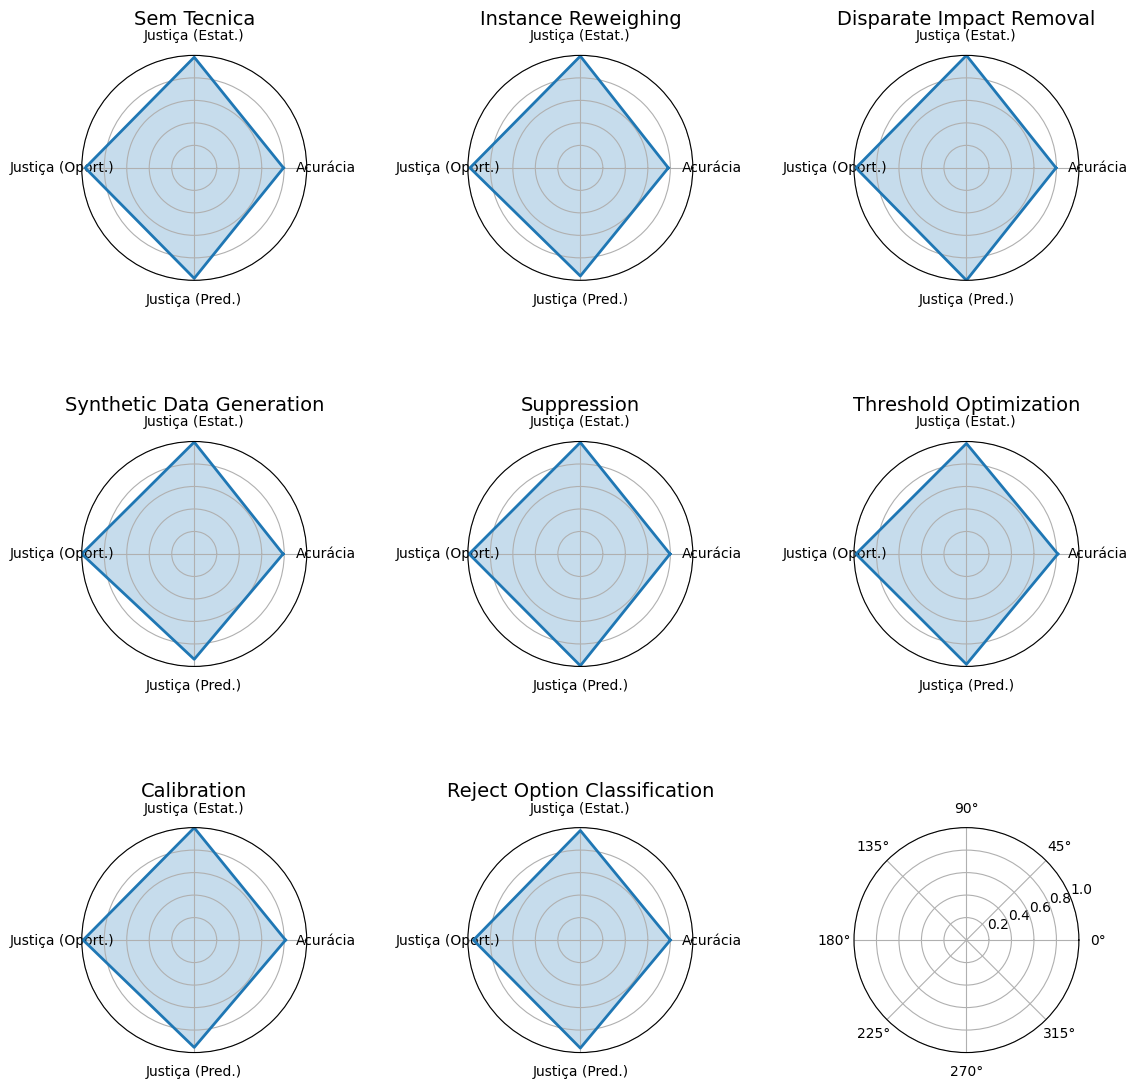

In [ ]:
grafico_radar(resultado_global['dataset_1_original']['perceptron'])

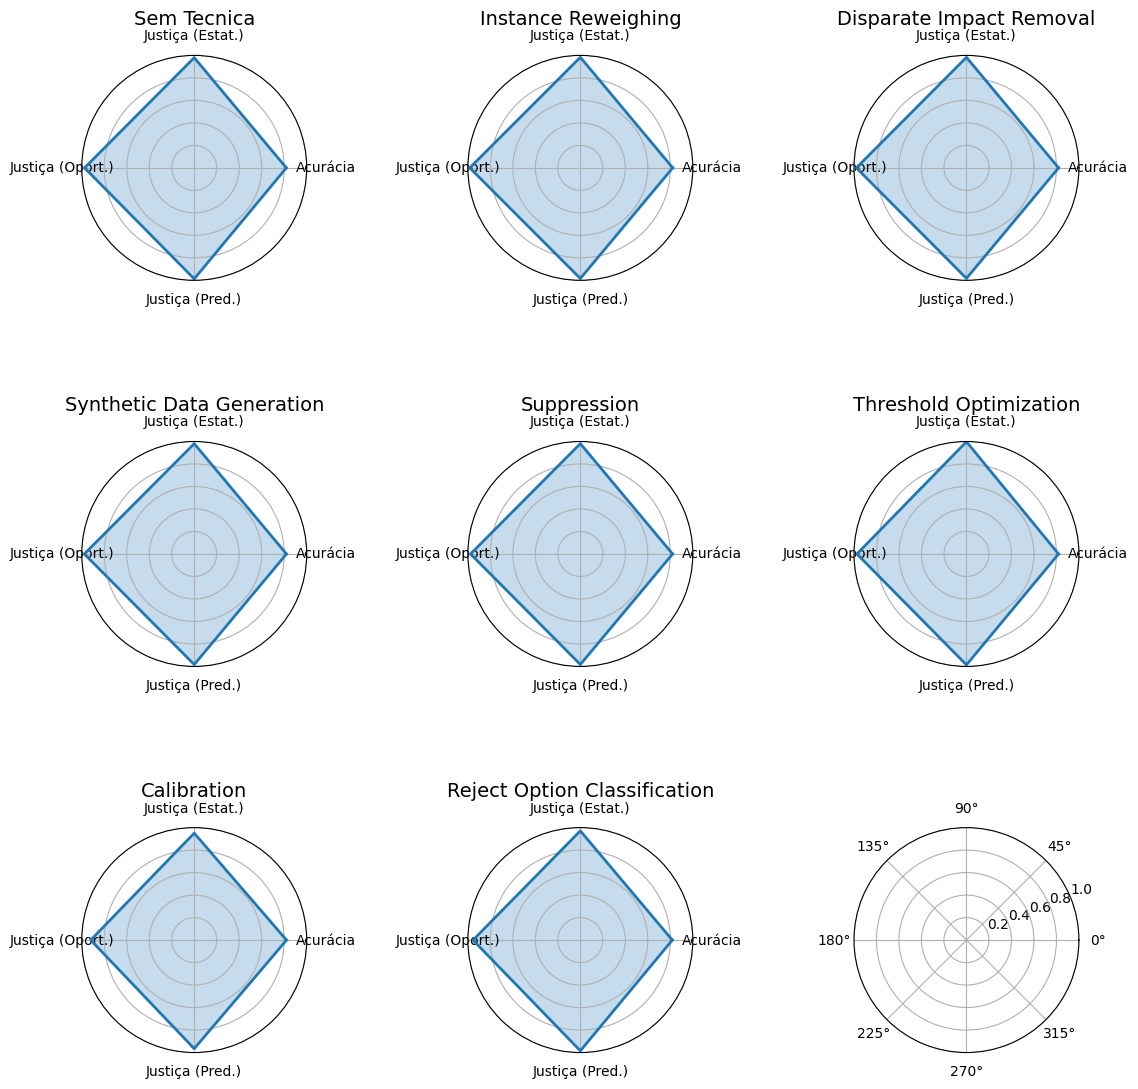

In [ ]:
grafico_radar(resultado_global['dataset_1_original']["random_forest"])

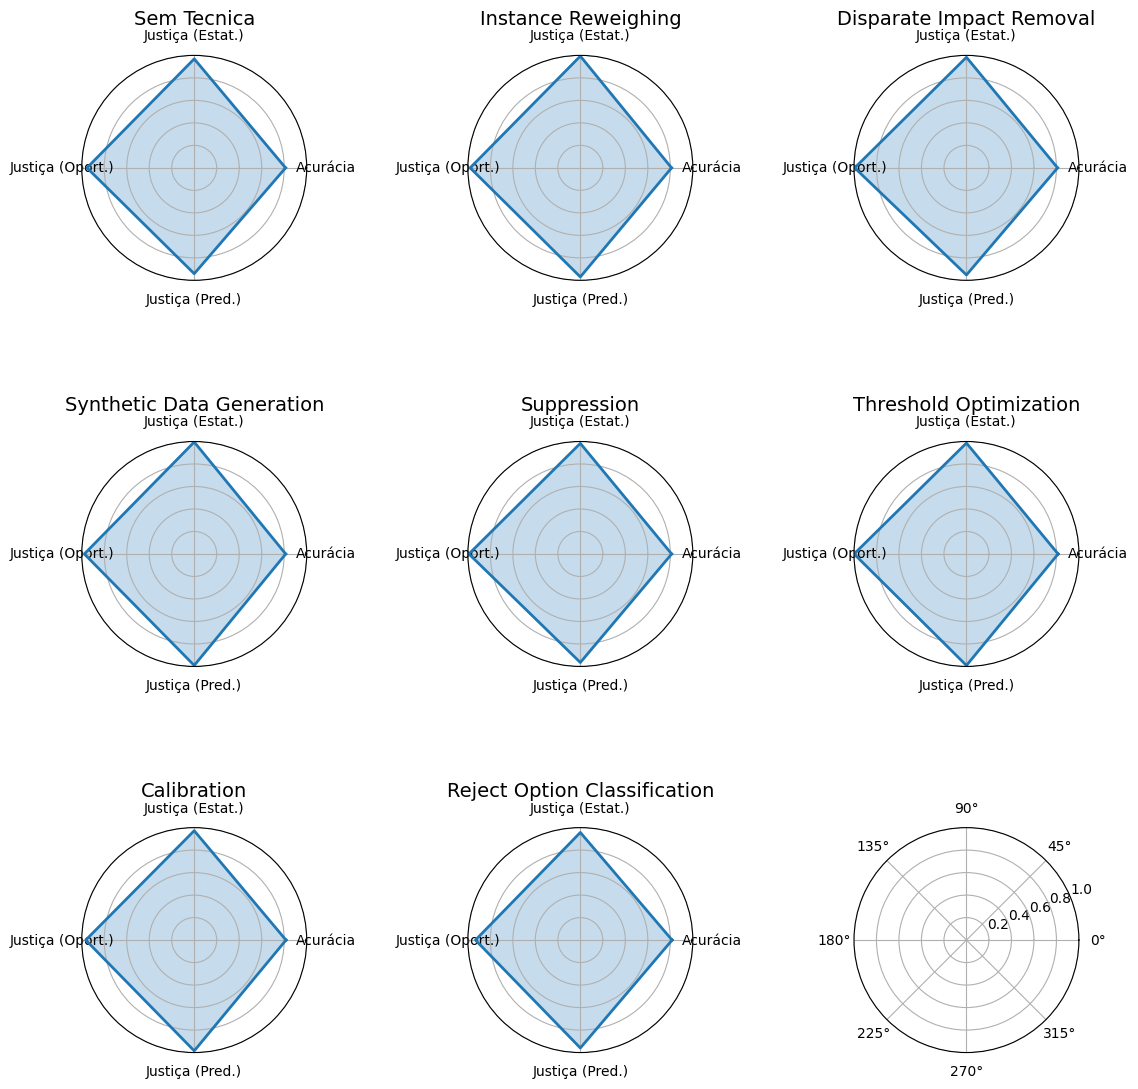

In [ ]:
grafico_radar(resultado_global['dataset_1_original']["regressão_logística"])

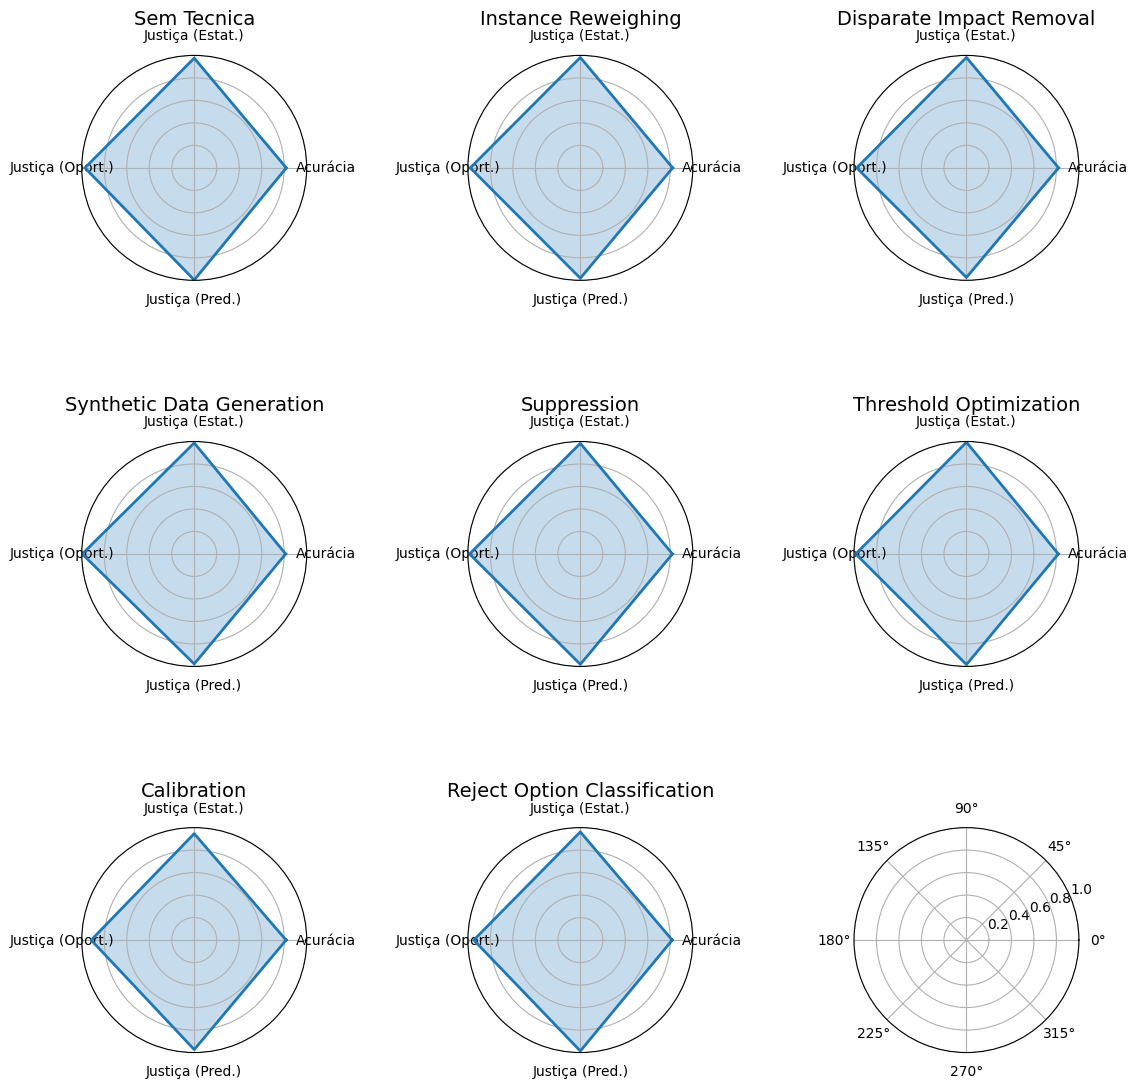

In [ ]:
grafico_radar(resultado_global['dataset_1_original']["xgboost"])

# Análise da ordem do gráfico de radar

In [ ]:
from itertools import permutations
import math

def encontrar_todas_permutacoes(vetor):
  print(f"Permutações para o vetor: {vetor}\n")
  print("Utiliza-se os angulos em radianos")
  perms = permutations(vetor, len(vetor))

  # Calcula a área para cada permutação
  resultados = []
  for perm in perms:
    print(perm)
    soma = 0
    for x in range(len(vetor)):
      soma += perm[x-1]*perm[x]/2*math.sin((2 * math.pi) /len(vetor))
      print(f"({perm[x]} * {perm[x-1]} / 2) * sen({(2 * math.pi) /len(vetor):.3f}) = {perm[x-1]*perm[x]/2*math.sin((2 * math.pi) /len(vetor)):.3f}")
    print(f"A soma das áreas é {soma:.3f}\n")
    resultados.append(soma)

  resultados.sort()
  for x in resultados:
    print(f"{x:.4f}", end=", ")

In [ ]:
encontrar_todas_permutacoes([0.9, 0.8, 0.5, 0.6])

Permutações para o vetor: [0.9, 0.8, 0.5, 0.6]

Utiliza-se os angulos em radianos
(0.9, 0.8, 0.5, 0.6)
(0.9 * 0.6 / 2) * sen(1.571) = 0.270
(0.8 * 0.9 / 2) * sen(1.571) = 0.360
(0.5 * 0.8 / 2) * sen(1.571) = 0.200
(0.6 * 0.5 / 2) * sen(1.571) = 0.150
A soma das áreas é 0.980

(0.9, 0.8, 0.6, 0.5)
(0.9 * 0.5 / 2) * sen(1.571) = 0.225
(0.8 * 0.9 / 2) * sen(1.571) = 0.360
(0.6 * 0.8 / 2) * sen(1.571) = 0.240
(0.5 * 0.6 / 2) * sen(1.571) = 0.150
A soma das áreas é 0.975

(0.9, 0.5, 0.8, 0.6)
(0.9 * 0.6 / 2) * sen(1.571) = 0.270
(0.5 * 0.9 / 2) * sen(1.571) = 0.225
(0.8 * 0.5 / 2) * sen(1.571) = 0.200
(0.6 * 0.8 / 2) * sen(1.571) = 0.240
A soma das áreas é 0.935

(0.9, 0.5, 0.6, 0.8)
(0.9 * 0.8 / 2) * sen(1.571) = 0.360
(0.5 * 0.9 / 2) * sen(1.571) = 0.225
(0.6 * 0.5 / 2) * sen(1.571) = 0.150
(0.8 * 0.6 / 2) * sen(1.571) = 0.240
A soma das áreas é 0.975

(0.9, 0.6, 0.8, 0.5)
(0.9 * 0.5 / 2) * sen(1.571) = 0.225
(0.6 * 0.9 / 2) * sen(1.571) = 0.270
(0.8 * 0.6 / 2) * sen(1.571) = 0.240
(0.5 *

In [ ]:
encontrar_todas_permutacoes([0.9, 0.9, 0.5, 0.3, 0.3])

Permutações para o vetor: [0.9, 0.9, 0.5, 0.3, 0.3]

Utiliza-se os angulos em radianos
(0.9, 0.9, 0.5, 0.3, 0.3)
(0.9 * 0.3 / 2) * sen(1.257) = 0.128
(0.9 * 0.9 / 2) * sen(1.257) = 0.385
(0.5 * 0.9 / 2) * sen(1.257) = 0.214
(0.3 * 0.5 / 2) * sen(1.257) = 0.071
(0.3 * 0.3 / 2) * sen(1.257) = 0.043
A soma das áreas é 0.842

(0.9, 0.9, 0.5, 0.3, 0.3)
(0.9 * 0.3 / 2) * sen(1.257) = 0.128
(0.9 * 0.9 / 2) * sen(1.257) = 0.385
(0.5 * 0.9 / 2) * sen(1.257) = 0.214
(0.3 * 0.5 / 2) * sen(1.257) = 0.071
(0.3 * 0.3 / 2) * sen(1.257) = 0.043
A soma das áreas é 0.842

(0.9, 0.9, 0.3, 0.5, 0.3)
(0.9 * 0.3 / 2) * sen(1.257) = 0.128
(0.9 * 0.9 / 2) * sen(1.257) = 0.385
(0.3 * 0.9 / 2) * sen(1.257) = 0.128
(0.5 * 0.3 / 2) * sen(1.257) = 0.071
(0.3 * 0.5 / 2) * sen(1.257) = 0.071
A soma das áreas é 0.785

(0.9, 0.9, 0.3, 0.3, 0.5)
(0.9 * 0.5 / 2) * sen(1.257) = 0.214
(0.9 * 0.9 / 2) * sen(1.257) = 0.385
(0.3 * 0.9 / 2) * sen(1.257) = 0.128
(0.3 * 0.3 / 2) * sen(1.257) = 0.043
(0.5 * 0.3 / 2) * sen(1.257)

In [ ]:
encontrar_todas_permutacoes([0.8, 0.7, 0.9, 1, 0.6])

Permutações para o vetor: [0.8, 0.7, 0.9, 1, 0.6]

Utiliza-se os angulos em radianos
(0.8, 0.7, 0.9, 1, 0.6)
(0.8 * 0.6 / 2) * sen(1.257) = 0.228
(0.7 * 0.8 / 2) * sen(1.257) = 0.266
(0.9 * 0.7 / 2) * sen(1.257) = 0.300
(1 * 0.9 / 2) * sen(1.257) = 0.428
(0.6 * 1 / 2) * sen(1.257) = 0.285
A soma das áreas é 1.507

(0.8, 0.7, 0.9, 0.6, 1)
(0.8 * 1 / 2) * sen(1.257) = 0.380
(0.7 * 0.8 / 2) * sen(1.257) = 0.266
(0.9 * 0.7 / 2) * sen(1.257) = 0.300
(0.6 * 0.9 / 2) * sen(1.257) = 0.257
(1 * 0.6 / 2) * sen(1.257) = 0.285
A soma das áreas é 1.488

(0.8, 0.7, 1, 0.9, 0.6)
(0.8 * 0.6 / 2) * sen(1.257) = 0.228
(0.7 * 0.8 / 2) * sen(1.257) = 0.266
(1 * 0.7 / 2) * sen(1.257) = 0.333
(0.9 * 1 / 2) * sen(1.257) = 0.428
(0.6 * 0.9 / 2) * sen(1.257) = 0.257
A soma das áreas é 1.512

(0.8, 0.7, 1, 0.6, 0.9)
(0.8 * 0.9 / 2) * sen(1.257) = 0.342
(0.7 * 0.8 / 2) * sen(1.257) = 0.266
(1 * 0.7 / 2) * sen(1.257) = 0.333
(0.6 * 1 / 2) * sen(1.257) = 0.285
(0.9 * 0.6 / 2) * sen(1.257) = 0.257
A soma das áreas 

# Testes